<a href="https://colab.research.google.com/github/andy-magallanes-1994/Proyecto-1---Sales-Data-for-Economics-Data-Analytics/blob/main/Proyect_1_Sales_Data_for_Economic_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishekrp1517/sales-data-for-economic-data-analysis")

print("Path to dataset files:", path)

100%|██████████| 3.09M/3.09M [00:00<00:00, 129MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abhishekrp1517/sales-data-for-economic-data-analysis/versions/2


# Acerca del Dataset
El conjunto de datos contiene información sobre las transacciones de venta, incluyendo detalles como la edad, el sexo, la ubicación y los productos comprados por el cliente. Incluye datos tanto sobre el coste del producto como sobre los ingresos generados por su venta, lo que permite calcular las ganancias y los márgenes de beneficio. La columna de cantidad proporciona información sobre el volumen de productos vendidos, que podría utilizarse para analizar las tendencias de ventas a lo largo del tiempo. El dataset incluye información sobre la edad y el sexo del cliente, que podría utilizarse para analizar el comportamiento de compra en diferentes grupos demográficos. Además agrega datos numéricos y categóricos, lo que requeriría diferentes tipos de técnicas de análisis y visualización. En general, proporciona una visión completa de las transacciones de venta, con potencial de análisis a múltiples niveles, incluyendo por producto, cliente y ubicación.
# Descripción de las columnas
Año: Esta columna representa el año en que se realizó la transacción. Puede utilizarse para rastrear tendencias a lo largo del tiempo o para filtrar los datos según un año específico o un rango de años.

Mes: Esta columna representa el mes en que se realizó la transacción. Puede utilizarse para rastrear tendencias a lo largo del tiempo o para filtrar los datos según un mes específico o un rango de meses.

Edad del cliente: Esta columna representa la edad del cliente. Puede utilizarse para segmentar a los clientes por rangos de edad o para analizar el comportamiento de compra de diferentes grupos de edad.

Género del cliente: Esta columna representa el género del cliente. Puede utilizarse para segmentar a los clientes por género o para analizar el comportamiento de compra de diferentes géneros.

País: Esta columna representa el país donde se realizó la transacción. Puede utilizarse para analizar las ventas por país o para filtrar los datos según un país específico o un rango de países.

Estado: Esta columna representa el estado donde se realizó la transacción. Puede utilizarse para analizar las ventas por estado o para filtrar los datos según un estado específico o un rango de estados.

Categoría de producto: Esta columna representa la categoría general del producto vendido. Puede utilizarse para analizar las ventas por categoría de producto o para filtrar los datos según una categoría específica.

Subcategoría: Esta columna representa la subcategoría específica del producto vendido. Puede utilizarse para analizar las ventas por subcategoría o para filtrar los datos según una subcategoría específica.

Cantidad: Esta columna representa la cantidad del producto vendido. Puede utilizarse para analizar el volumen de ventas o para calcular los ingresos totales generados por un producto o categoría de producto en particular.

Costo unitario: Esta columna representa el coste de producir o adquirir una unidad del producto. Puede utilizarse para calcular márgenes de beneficio o para comparar los costes de diferentes productos o categorías de productos.

Precio unitario: Esta columna representa el precio al que se vendió una unidad del producto. Puede utilizarse para analizar estrategias de precios o para comparar los precios de diferentes productos o categorías de productos.

Costo: Esta columna representa el costo total de los productos vendidos, calculado como el producto de la cantidad por el costo unitario. Puede utilizarse para analizar la estructura de costos del negocio o para calcular el margen de beneficio de cada venta.

Ingresos: Esta columna representa los ingresos totales generados por las ventas, calculados como el producto de la cantidad por el precio unitario. Puede utilizarse para analizar el rendimiento general de las ventas del negocio o para calcular el beneficio generado por cada venta.

# Objetivo de análisis

* Evaluar aspectos del negocio que permitan: incrementar la rentabilidad, disminuir costos o preveer tendencias futuras del mercado (por ej. cambios en gustos y preferencias del cliente, detectar incrementos y disminuciones de demanda, etc.)

## Carga y Exploración del Conjunto de Datos

Corregir el nombre del archivo CSV, cargar el conjunto de datos de ventas en un DataFrame de pandas y realizar una exploración inicial para comprender su estructura, tipos de datos, estadísticas descriptivas y la presencia de posibles valores faltantes o atípicos.


In [ ]:
import os
import pandas as pd

# Corregir el camino para encontrar el archivo CSV del DataBase basado en la salida os.listdir
csv_file_path = os.path.join(path, 'salesforcourse-4fe2kehu.csv')

# Cargar el archivo CSV en un DF de Pandas
df = pd.read_csv(csv_file_path)
print("\nDataFrame cargado satisfactoriamente.")

# Muestra las primeras 5 filas del DF
print("\nPrimeras 5 filas del DataFrame:")
print(df.head())

# Muestra un resumen del DF, incluyendo tipos de datos y valores no nulos
print("\nInformación del DataFrame:")
df.info()

# Generar estadísticas descriptivas para columnas numéricas
print("\nEstadísticas Descriptivas para Columnas Numéricas:")
print(df.describe())

# Buscar valores nulos en cada columna
print("\nValores Nulos por Columna:")
print(df.isnull().sum())


DataFrame cargado satisfactoriamente.

Primeras 5 filas del DataFrame:
   index       Date    Year     Month  Customer Age Customer Gender  \
0      0  2/19/2016  2016.0  February          29.0               F   
1      1  2/20/2016  2016.0  February          29.0               F   
2      2  2/27/2016  2016.0  February          29.0               F   
3      3  3/12/2016  2016.0     March          29.0               F   
4      4  3/12/2016  2016.0     March          29.0               F   

         Country       State Product Category     Sub Category  Quantity  \
0  United States  Washington      Accessories  Tires and Tubes       1.0   
1  United States  Washington         Clothing           Gloves       2.0   
2  United States  Washington      Accessories  Tires and Tubes       3.0   
3  United States  Washington      Accessories  Tires and Tubes       2.0   
4  United States  Washington      Accessories  Tires and Tubes       3.0   

   Unit Cost  Unit Price   Cost  Revenue  Co

## Preparación y Limpieza de Datos

Primero verificar si la columna 'Column1' existe antes de intentar eliminarla. Continuar con la eliminación de filas con valores nulos, la conversión de tipos de datos para 'Date', 'Year' y 'Customer Age', y la conversión de columnas categóricas a tipo 'category', tal como se especificó.


In [ ]:
import numpy as np

# 1. Eliminar la columna 'Column1' debido a la gran cantidad de valores faltantes.
# Verificar si 'Column1' existe antes de intentar eliminarla.
if 'Column1' in df.columns:
    print(f"Shape antes de borrar 'Column1': {df.shape}")
    df = df.drop('Column1', axis=1)
    print(f"Shape después de borrar 'Column1': {df.shape}")
else:
    print("'Column1' no se encontró en el DataFrame. Continuando sin eliminarla.")

# 2. Eliminar las filas que contengan cualquier valor nulo en las columnas restantes
print(f"Shape antes de borrar filas con valores nulos: {df.shape}")
df = df.dropna()
print(f"Shape después de borrar filas con valores nulos: {df.shape}")

# 3. Convertir la columna 'Date' al tipo de dato datetime.
df['Date'] = pd.to_datetime(df['Date'])

# 4. Convertir las columnas 'Year' y 'Customer Age' al tipo de dato entero.
# Convertir a Int64 para manejar posibles NaN si aún existieran, luego a int
df['Year'] = df['Year'].astype(int)
df['Customer Age'] = df['Customer Age'].astype(int)

# 5. Convertir las columnas categóricas al tipo de dato 'category'.
categorical_cols = ['Customer Gender', 'Country', 'State', 'Product Category', 'Sub Category', 'Month']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 6. Mostrar un resumen del DataFrame actualizado
print("\nDataFrame actualizado:")
df.info()
print("\nValores Nulos por Columna (después de limpieza):")
print(df.isnull().sum())

Shape antes de borrar 'Column1': (34867, 16)
Shape después de borrar 'Column1': (34867, 15)
Shape antes de borrar filas con valores nulos: (34867, 15)
Shape después de borrar filas con valores nulos: (34866, 15)

DataFrame actualizado:
<class 'pandas.core.frame.DataFrame'>
Index: 34866 entries, 0 to 34865
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             34866 non-null  int64         
 1   Date              34866 non-null  datetime64[ns]
 2   Year              34866 non-null  int64         
 3   Month             34866 non-null  category      
 4   Customer Age      34866 non-null  int64         
 5   Customer Gender   34866 non-null  category      
 6   Country           34866 non-null  category      
 7   State             34866 non-null  category      
 8   Product Category  34866 non-null  category      
 9   Sub Category      34866 non-null  category      
 10  Quantit

## Ingeniería de Características y Cálculo de Métricas Clave

Crear nuevas características clave como 'Beneficio' y 'Margen de Beneficio' a partir de las columnas existentes 'Revenue' y 'Cost'. Además, extraer características temporales como 'Quarter' y 'Day of Week' de la columna 'Date' para enriquecer el análisis de tendencias y estacionalidad.


In [ ]:
import numpy as np

# 1. Calcular la columna 'Beneficio'
df['Beneficio'] = df['Revenue'] - df['Cost']

# 2. Calcular la columna 'Margen de Beneficio'
# Evitar división por cero si 'Revenue' es 0
df['Margen de Beneficio'] = np.where(df['Revenue'] != 0, df['Beneficio'] / df['Revenue'], 0)

# 3. Extraer el trimestre (quarter) de la columna 'Date'
df['Quarter'] = df['Date'].dt.quarter.astype('category')

# 4. Extraer el día de la semana (day of week) de la columna 'Date'
df['Day of Week'] = df['Date'].dt.day_name().astype('category')

# 5. Mostrar las primeras 5 filas del DataFrame para verificar las nuevas columnas
print("\nPrimeras 5 filas del DataFrame con nuevas columnas:")
print(df.head())

# 6. Mostrar la información del DataFrame para confirmar los tipos de datos
print("\nInformación del DataFrame con nuevas columnas:")
df.info()


Primeras 5 filas del DataFrame con nuevas columnas:
   index       Date  Year     Month  Customer Age Customer Gender  \
0      0 2016-02-19  2016  February            29               F   
1      1 2016-02-20  2016  February            29               F   
2      2 2016-02-27  2016  February            29               F   
3      3 2016-03-12  2016     March            29               F   
4      4 2016-03-12  2016     March            29               F   

         Country       State Product Category     Sub Category  Quantity  \
0  United States  Washington      Accessories  Tires and Tubes       1.0   
1  United States  Washington         Clothing           Gloves       2.0   
2  United States  Washington      Accessories  Tires and Tubes       3.0   
3  United States  Washington      Accessories  Tires and Tubes       2.0   
4  United States  Washington      Accessories  Tires and Tubes       3.0   

   Unit Cost  Unit Price   Cost  Revenue  Beneficio  Margen de Beneficio  \

## Análisis Exploratorio de Datos (EDA) para Objetivos de Negocio

Realizar un Análisis Exploratorio de Datos (EDA) para visualizar las distribuciones de variables clave, identificar patrones de ventas por categoría de producto, ubicación, edad y género del cliente, y analizar la evolución de los ingresos, costos y beneficios a lo largo del tiempo, con un enfoque en la rentabilidad, los costos y las tendencias.


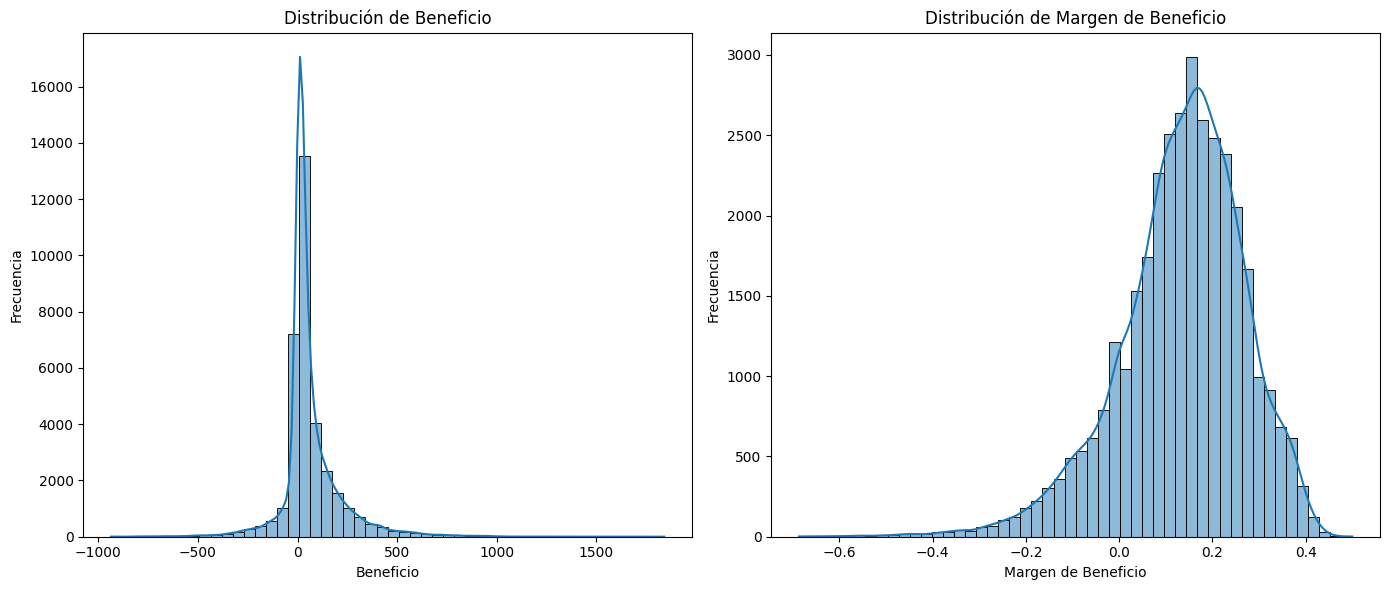

/tmp/ipython-input-1292940682.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_category_summary = df.groupby('Product Category')[['Beneficio', 'Revenue']].sum().sort_values(by='Beneficio', ascending=False)


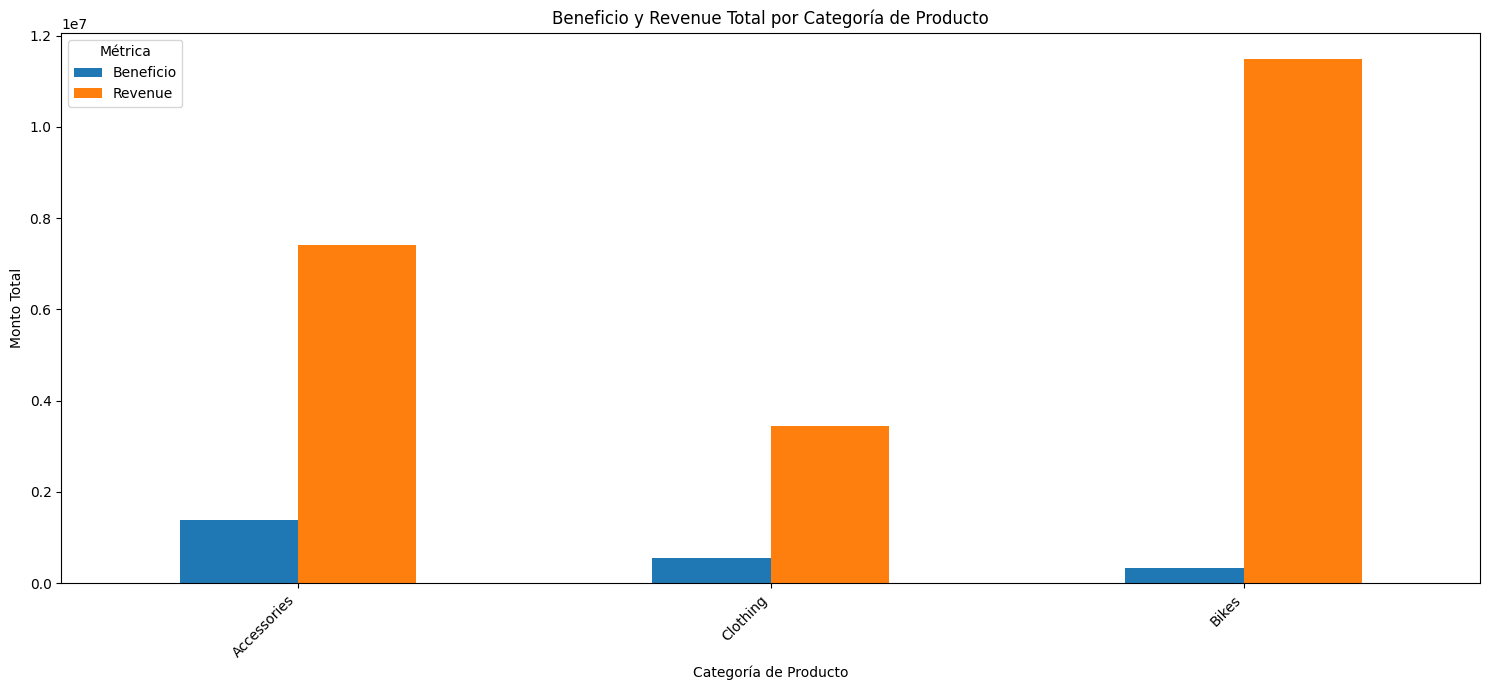

/tmp/ipython-input-1292940682.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_gender_summary = df.groupby('Customer Gender')[['Beneficio', 'Revenue']].mean().sort_values(by='Beneficio', ascending=False)


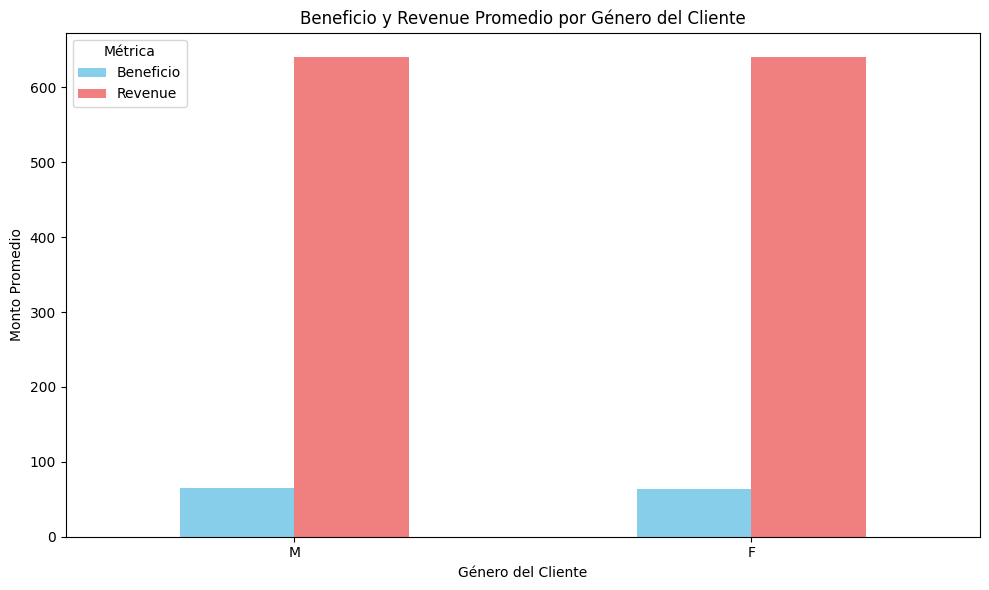

/tmp/ipython-input-1292940682.py:49: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_summary = df.set_index('Date').resample('M')[['Revenue', 'Cost', 'Beneficio']].sum()


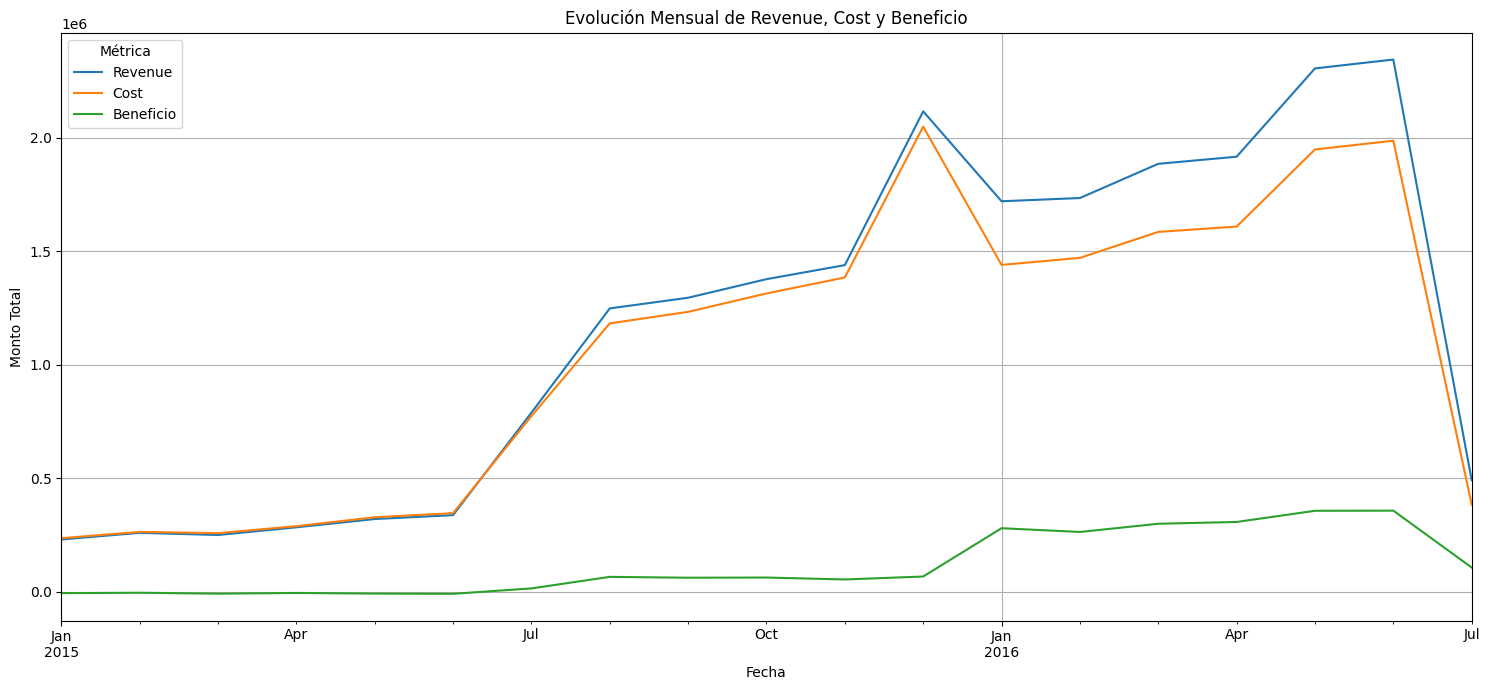

/tmp/ipython-input-1292940682.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quarter_profit = df.groupby('Quarter')['Beneficio'].sum().sort_index()
/tmp/ipython-input-1292940682.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarter_profit.index, y=quarter_profit.values, palette='viridis')
/tmp/ipython-input-1292940682.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_profit = df.groupby('Day of Week')['Beneficio'].sum().reindex(day_of_week

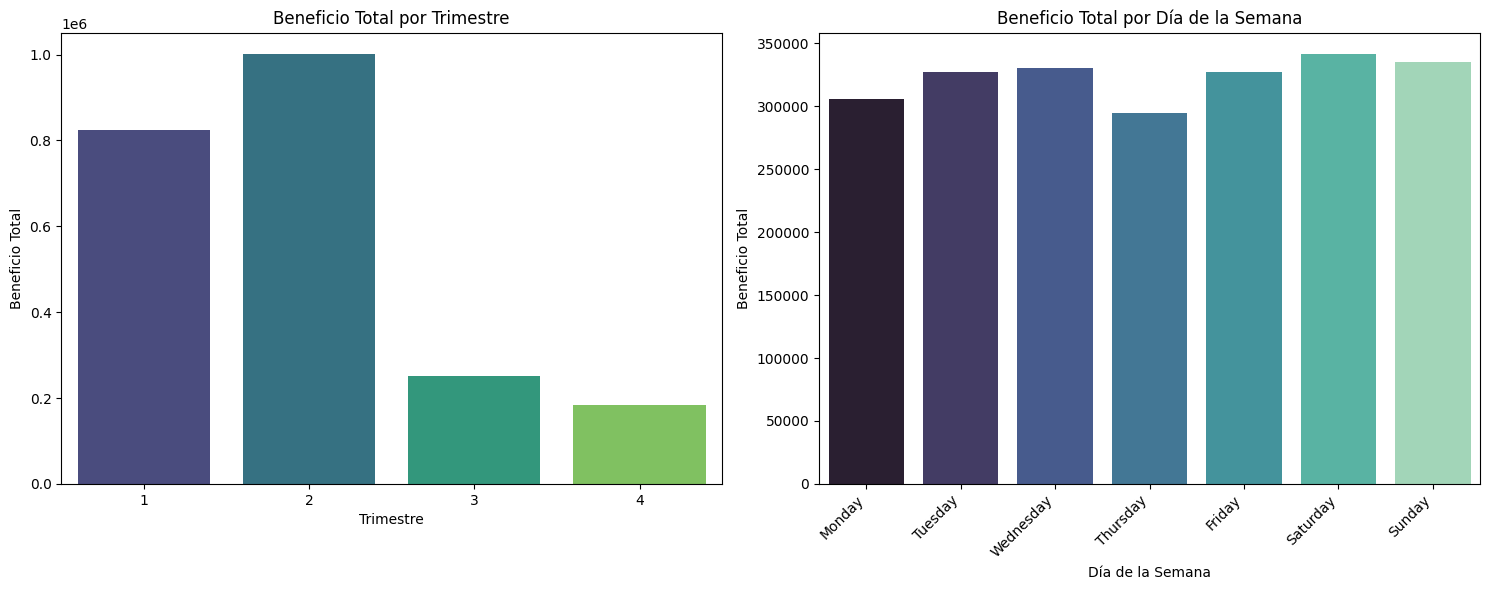

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustar el tamaño de las figuras para una mejor visualización
plt.rcParams['figure.figsize'] = (12, 7)

# 1. Distribución de 'Beneficio' y 'Margen de Beneficio'
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Beneficio'], bins=50, kde=True)
plt.title('Distribución de Beneficio')
plt.xlabel('Beneficio')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['Margen de Beneficio'], bins=50, kde=True)
plt.title('Distribución de Margen de Beneficio')
plt.xlabel('Margen de Beneficio')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# 2. 'Beneficio' y 'Revenue' por 'Product Category'
product_category_summary = df.groupby('Product Category')[['Beneficio', 'Revenue']].sum().sort_values(by='Beneficio', ascending=False)

product_category_summary.plot(kind='bar', figsize=(15, 7))
plt.title('Beneficio y Revenue Total por Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Monto Total')
plt.legend(title='Métrica')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. 'Beneficio' y 'Revenue' promedio por 'Customer Gender'
customer_gender_summary = df.groupby('Customer Gender')[['Beneficio', 'Revenue']].mean().sort_values(by='Beneficio', ascending=False)

customer_gender_summary.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Beneficio y Revenue Promedio por Género del Cliente')
plt.xlabel('Género del Cliente')
plt.ylabel('Monto Promedio')
plt.legend(title='Métrica')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Evolución mensual de 'Revenue', 'Cost' y 'Beneficio'
monthly_summary = df.set_index('Date').resample('M')[['Revenue', 'Cost', 'Beneficio']].sum()

plt.figure(figsize=(15, 7))
monthly_summary.plot(kind='line', ax=plt.gca())
plt.title('Evolución Mensual de Revenue, Cost y Beneficio')
plt.xlabel('Fecha')
plt.ylabel('Monto Total')
plt.legend(title='Métrica')
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. 'Beneficio' total por 'Quarter' y 'Day of Week'
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
quarter_profit = df.groupby('Quarter')['Beneficio'].sum().sort_index()
sns.barplot(x=quarter_profit.index, y=quarter_profit.values, palette='viridis')
plt.title('Beneficio Total por Trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Beneficio Total')

plt.subplot(1, 2, 2)
day_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_profit = df.groupby('Day of Week')['Beneficio'].sum().reindex(day_of_week_order)
sns.barplot(x=day_profit.index, y=day_profit.values, palette='mako')
plt.title('Beneficio Total por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Beneficio Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Definir el Problema de Machine Learning y la Variable Objetivo

Definir claramente qué variable se intentará predecir (la 'variable objetivo') y el tipo de problema de Machine Learning (por ejemplo, regresión para predecir el beneficio o las ventas futuras, clasificación para identificar clientes de alto valor, o análisis de series de tiempo para prever la demanda), basándose en el EDA y los objetivos de negocio.


## Definición del Problema de Machine Learning y la Variable Objetivo

### Variable Objetivo:

Para abordar los objetivos de incrementar la rentabilidad y prever tendencias futuras del mercado, la **variable objetivo principal** será el **'Beneficio'**.

### Tipo de Problema de Machine Learning:

El problema se enmarca como un **problema de regresión**. Si el objetivo es predecir el beneficio futuro en función del tiempo, también podría considerarse un **problema de series de tiempo**.

### Justificación:

1.  **Relevancia para la Rentabilidad:** El 'Beneficio' es una métrica directa de la rentabilidad del negocio (Ingresos - Costo). Predecir el beneficio nos permitirá:
    *   Identificar factores clave que impulsan o restringen las ganancias.
    *   Evaluar el impacto potencial de nuevas estrategias de precios, productos o marketing.
    *   Optimizar operaciones para maximizar la rentabilidad.

2.  **Identificación de Tendencias y Estacionalidad:** El EDA reveló tendencias mensuales de 'Beneficio' y variaciones por trimestre y día de la semana. Un modelo de regresión o series de tiempo podría capturar estas dinámicas para prever el beneficio futuro, ayudando a la planificación estratégica y a la toma de decisiones proactivas.

3.  **Análisis por Segmentos:** Al poder predecir el beneficio, podríamos identificar qué categorías de productos, ubicaciones geográficas o segmentos de clientes (edad, género) son los más rentables o los que tienen mayor potencial de crecimiento, permitiendo una asignación de recursos más eficiente.

4.  **Optimización de Costos:** Aunque el 'Beneficio' es el objetivo, al entender cómo diferentes variables impactan los ingresos y los costos (que contribuyen al beneficio), el modelo puede indirectamente ayudar a señalar áreas donde los costos podrían ser optimizados sin comprometer los ingresos, o donde una inversión en costos podría generar un retorno de beneficio significativo.

Al predecir el 'Beneficio', la empresa puede tomar decisiones informadas para optimizar sus estrategias de ventas, marketing y operaciones, con el fin último de aumentar la rentabilidad y adaptarse mejor a las condiciones del mercado.

## Dividir los Datos para el Modelado

Dividir el conjunto de datos en características (X) y la variable objetivo (y), y luego separarlos en conjuntos de entrenamiento y prueba para preparar el modelado.


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Definir la variable objetivo (y)
y = df['Beneficio']

# 2. Definir las características (X)
# Excluir 'index', 'Date', 'Revenue', 'Cost', 'Beneficio' y 'Margen de Beneficio'
# Crear una lista de columnas a excluir
columns_to_exclude = ['index', 'Date', 'Revenue', 'Cost', 'Beneficio', 'Margen de Beneficio']
X = df.drop(columns=columns_to_exclude, axis=1)

# 3. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Imprimir las formas de los conjuntos para verificar la división
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)


Forma de X_train: (27892, 13)
Forma de X_test: (6974, 13)
Forma de y_train: (27892,)
Forma de y_test: (6974,)


# Hallazgos Clave del Análisis de Datos

**Ingeniería de Características**: Se crearon cuatro nuevas características:
* Beneficio: Calculado como 'Ingresos' - 'Costos'.
* Margen de Beneficio: Calculado como 'Beneficio' / 'Ingresos', gestionando la división entre cero.
* Trimestre: Extraído como el número del trimestre de la columna 'Fecha' y convertido a un tipo categórico.
* Día de la Semana: Extraído como el nombre del día de la columna 'Fecha' y convertido a un tipo categórico.
  
**Análisis Exploratorio de Datos (EDA)**:
* Se generaron visualizaciones para explorar las distribuciones de 'Beneficio' y 'Margen de Beneficio', el beneficio total y los ingresos por 'Categoría de Producto' y los valores promedio por 'Género del Cliente'. * Se analizaron las tendencias temporales, mostrando la evolución mensual de Ingresos, Costos y Beneficios, así como el beneficio total por trimestre y día de la semana.
* No se proporcionaron hallazgos cuantitativos específicos de la EDA en la solicitud de cotización, más allá de confirmar la generación exitosa de gráficos y la resolución de las advertencias.

**Definición del Problema de Aprendizaje Automático:**
* La variable objetivo principal para la tarea de aprendizaje automático se definió como "Beneficio".
* El problema se clasificó como un problema de regresión, con la posibilidad de considerar un problema de series temporales si el objetivo específico es predecir las ganancias futuras a lo largo del tiempo.
* La elección se justificó por su relevancia directa para la rentabilidad del negocio, la capacidad de identificar tendencias y estacionalidad, facilitar el análisis de segmentos y contribuir a la optimización de costos.

**División de Datos**: El conjunto de datos se dividió correctamente en características (X) y la variable objetivo (y), y posteriormente en conjuntos de entrenamiento y prueba.
* Beneficio se estableció como la variable objetivo (y).
* Las características (X) incluyeron todas las columnas excepto "Índice", "Fecha", "Ingresos", "Costo", "Beneficio" y "Margen de Beneficio".
* Los datos se dividieron en un 80 % para entrenamiento y un 20 % para pruebas (random_state=42), lo que resultó en:

     *X_train: (27892, 13)

     *X_test: (6974, 13)

     *y_train: (27892,)

     *y_test: (6974,)


### Perspectivas o Próximos Pasos

* La creación de "Beneficio" y "Margen de Beneficio" como métricas centrales, combinadas con características temporales, proporciona una base sólida para predecir la rentabilidad, alineándose directamente con los objetivos de negocio para mejorar el rendimiento financiero.
* El problema de regresión definido, centrado en "Beneficio", sienta las bases para el desarrollo de un modelo predictivo que pueda identificar los factores clave de las ganancias y pronosticar tendencias futuras, lo que permite una planificación estratégica proactiva. El siguiente paso debe consistir en seleccionar y entrenar modelos de regresión adecuados, seguidos de una evaluación rigurosa.

## POSIBLES CURSOS DE PREDICCIÓN

1. **Predicción del Beneficio por Transacción Futura**:
* Ejemplo: Predecir el beneficio esperado de una venta individual basándose en las características del cliente (edad, género), el producto (categoría, subcategoría), la ubicación (país, estado) y el momento de la venta (mes, trimestre, día de la semana).
* Beneficio para la Empresa:
Optimización de Precios: Identificar productos o segmentos que consistentemente generan bajo beneficio para ajustar precios o estrategias de marketing.
Gestión de Inventario: Priorizar productos con alto potencial de beneficio.
Personalización de Ofertas: Ofrecer descuentos o promociones específicas a clientes donde se espera un beneficio marginal bajo, o viceversa, para maximizar el beneficio total.
2. **Predicción del Beneficio Total Mensual/Trimestral**:
* Ejemplo: Estimar el beneficio total que la empresa generará en el próximo mes o trimestre, considerando las tendencias históricas, estacionalidad y características de los productos o clientes esperados.
* Beneficio para la Empresa:
Planificación Financiera: Ayudar en la elaboración de presupuestos y la asignación de recursos.
Evaluación de Rendimiento: Establecer objetivos de rendimiento realistas y monitorear el progreso.
Anticipación de Necesidades: Prever períodos de bajo beneficio para implementar campañas de marketing preventivas o ajustar operaciones.
3. **Identificación de Factores Clave que Impulsan el Beneficio**:
* Ejemplo: Analizar qué características (como categoría de producto, estado, edad del cliente o incluso el día de la semana) tienen el mayor impacto en el 'Beneficio'. Por ejemplo, el modelo podría revelar que las ventas de una 'Subcategoría' específica en un 'País' particular durante el 'Primer Trimestre' son las más rentables.
* Beneficio para la Empresa:
Estrategia de Producto: Enfocarse en desarrollar y promocionar los productos más rentables.
Expansión de Mercado: Identificar regiones geográficas o segmentos de clientes con mayor potencial de beneficio.
Optimización de Marketing: Dirigir campañas a los segmentos más lucrativos o a aquellos con mayor potencial de mejora.
4. **Detección de Anomalías o Disminuciones de Beneficio**:
* Ejemplo: Usar el modelo para detectar cuando el beneficio real de una transacción, producto o período es significativamente menor de lo predicho, indicando una posible anomalía o un problema subyacente (por ejemplo, costos excesivos, precios bajos, problemas de calidad).
* Beneficio para la Empresa:
Control de Calidad y Costos: Identificar rápidamente productos o procesos que están erosionando los márgenes.
Reacción Rápida: Tomar medidas correctivas a tiempo para mitigar pérdidas.
5. **Predicción de la Demanda y su Impacto en el Beneficio**:
* Ejemplo: Aunque el objetivo directo es el 'Beneficio', al entender la relación entre 'Cantidad' (demanda) y 'Beneficio', se pueden hacer predicciones indirectas sobre cómo los cambios en la demanda de ciertos productos afectarán las ganancias. Esto puede ser especialmente relevante si el modelo incorpora características relacionadas con la demanda.
* Beneficio para la Empresa:
Gestión de Cadena de Suministro: Asegurar que los productos de alto beneficio estén siempre en stock.
Marketing Estratégico: Promover productos de alta demanda y alto beneficio.

# Preparación de los datos
Se realiza procede con los pasos previos para alimentar cualquier modelo de Machine Learning, para ello transformaremos las características (categóricas y numéricas) del conjunto de datos en un formato adecuado para los algoritmos.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Identificar columnas categóricas y numéricas
categorical_features = ['Month', 'Customer Gender', 'Country', 'State', 'Product Category', 'Sub Category', 'Quarter', 'Day of Week']
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Excluir las categóricas ya listadas de las numéricas si se superponen (no deberían, pero por seguridad)
numerical_features = [f for f in numerical_features if f not in categorical_features]

# Crear el ColumnTransformer para aplicar OneHotEncoder solo a las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Mantener las columnas no especificadas (numéricas) tal cual
)

# Aplicar el preprocesamiento a los conjuntos de entrenamiento y prueba
X_train_processed = preprocessor.fit_transform(X_train).toarray() # Convertir a array denso
X_test_processed = preprocessor.transform(X_test).toarray()   # Convertir a array denso

# Obtener los nombres de las columnas para las características transformadas
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(onehot_feature_names) + numerical_features

# Convertir los arrays resultantes a DataFrames
X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

print("\nPrimeras 5 filas de X_train_processed:")
display(X_train_processed.head())

X_train_processed shape: (27892, 95)
X_test_processed shape: (6974, 95)

Primeras 5 filas de X_train_processed:


,Month_April,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,...,Day of Week_Saturday,Day of Week_Sunday,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday,Year,Customer Age,Quantity,Unit Cost,Unit Price
24328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2016.0,50.0,2.0,15.00,20.5
5096,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2015.0,41.0,3.0,38.33,54.0
14118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,2015.0,23.0,2.0,150.00,175.0
18429,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,2016.0,30.0,2.0,35.00,42.0
17957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,2015.0,37.0,1.0,455.00,543.0


# Escalado de características
Estandarización de las características numéricas y normalización

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identificar las columnas numéricas que necesitan escalado
# Estas son las columnas que no fueron One-Hot Encoded
# Ya las tenemos en la lista 'numerical_features' del paso anterior

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar el escalado a las características numéricas en los conjuntos procesados
# Fit solo en el entrenamiento y transform en ambos
X_train_processed[numerical_features] = scaler.fit_transform(X_train_processed[numerical_features])
X_test_processed[numerical_features] = scaler.transform(X_test_processed[numerical_features])

print("Características numéricas escaladas con éxito.")
print("\nPrimeras 5 filas de X_train_processed después del escalado:")
display(X_train_processed.head())

print("\nEstadísticas descriptivas de las columnas numéricas en X_train_processed (después del escalado):")
display(X_train_processed[numerical_features].describe())

Características numéricas escaladas con éxito.

Primeras 5 filas de X_train_processed después del escalado:


,Month_April,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,...,Day of Week_Saturday,Day of Week_Sunday,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday,Year,Customer Age,Quantity,Unit Cost,Unit Price
24328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.870426,1.229207,-0.003698,-0.683318,-0.702840
5096,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,-1.148863,0.418168,1.224185,-0.635714,-0.638986
14118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,-1.148863,-1.203910,-0.003698,-0.407854,-0.408350
18429,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.870426,-0.573102,-0.003698,-0.642509,-0.661859
17957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,-1.148863,0.057707,-1.231581,0.214491,0.293088



Estadísticas descriptivas de las columnas numéricas en X_train_processed (después del escalado):


,Year,Customer Age,Quantity,Unit Cost,Unit Price
count,2.789200e+04,2.789200e+04,2.789200e+04,2.789200e+04,2.789200e+04
mean,-4.707231e-14,-8.814276e-17,2.108039e-16,-2.827701e-15,-2.069572e-15
std,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00
min,-1.148863e+00,-1.744602e+00,-1.231581e+00,-7.125582e-01,-7.406440e-01
25%,-1.148863e+00,-7.533325e-01,-1.231581e+00,-6.221039e-01,-6.402570e-01
50%,8.704256e-01,-1.225243e-01,-3.697912e-03,-4.078539e-01,-3.980257e-01
75%,8.704256e-01,6.885147e-01,1.224185e+00,2.144914e-01,2.492481e-01
max,8.704256e-01,4.563479e+00,1.224185e+00,5.652361e+00,6.897664e+00


# Entrenamiento de Modelos para la Predicción de Beneficio. RandomRegressor
Dado que el 'Beneficio' puede depender de interacciones complejas entre muchas variables (edad del cliente, tipo de producto, ubicación, estacionalidad, etc.), un modelo como Random Forest es muy adecuado. Puede capturar relaciones no lineales y patrones intrincados que un modelo lineal no podría.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Entrenar un modelo de Regresión Lineal
print("\nEntrenando Modelo de Regresión Lineal...")
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
print("Modelo de Regresión Lineal entrenado con éxito.")

# 2. Entrenar un modelo RandomForestRegressor
print("\nEntrenando Modelo RandomForestRegressor... (Esto puede tardar unos minutos)")
# Ajustar n_estimators para un balance entre rendimiento y tiempo de ejecución
# random_state para reproducibilidad
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los núcleos disponibles
rf_model.fit(X_train_processed, y_train)
print("Modelo RandomForestRegressor entrenado con éxito.")

print("\nAmbos modelos han sido entrenados y están listos para la evaluación.")


Entrenando Modelo de Regresión Lineal...
Modelo de Regresión Lineal entrenado con éxito.

Entrenando Modelo RandomForestRegressor... (Esto puede tardar unos minutos)
Modelo RandomForestRegressor entrenado con éxito.

Ambos modelos han sido entrenados y están listos para la evaluación.


# Evaluación de Modelos para la Predicción de Beneficio

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("\nEvaluando Modelo de Regresión Lineal...")
# Realizar predicciones con el modelo lineal
y_pred_linear = linear_model.predict(X_test_processed)

# Calcular métricas de evaluación para el modelo lineal
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"\nMétricas para el Modelo de Regresión Lineal:")
print(f"  MAE: {mae_linear:.2f}")
print(f"  MSE: {mse_linear:.2f}")
print(f"  RMSE: {rmse_linear:.2f}")
print(f"  R2 Score: {r2_linear:.2f}")

print("\nEvaluando Modelo RandomForestRegressor...")
# Realizar predicciones con el modelo Random Forest
y_pred_rf = rf_model.predict(X_test_processed)

# Calcular métricas de evaluación para el modelo Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nMétricas para el Modelo RandomForestRegressor:")
print(f"  MAE: {mae_rf:.2f}")
print(f"  MSE: {mse_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R2 Score: {r2_rf:.2f}")

print("\nLa evaluación de ambos modelos ha sido completada.")


Evaluando Modelo de Regresión Lineal...

Métricas para el Modelo de Regresión Lineal:
  MAE: 37.65
  MSE: 3904.87
  RMSE: 62.49
  R2 Score: 0.83

Evaluando Modelo RandomForestRegressor...

Métricas para el Modelo RandomForestRegressor:
  MAE: 10.38
  MSE: 951.21
  RMSE: 30.84
  R2 Score: 0.96

La evaluación de ambos modelos ha sido completada.


Al ver los resultados, queda claro que el RandomForestRegressor superó al Modelo de Regresión Lineal en todas las métricas, especialmente en el R2 Score, lo que indica que es mucho más efectivo para explicar y predecir la variabilidad del 'Beneficio'.

### **Importancia Global de las Características (`Feature Importance`)**

Vamos a extraer y visualizar la importancia de las características del `RandomForestRegressor` entrenado. Esto nos dirá qué características fueron, en promedio, más influyentes para el modelo al hacer predicciones de 'Beneficio' en todo el conjunto de datos.

Top 10 Características más importantes (Global):


,Feature,Importance
94,Unit Price,0.513625
15,Country_Germany,0.107379
93,Unit Cost,0.107170
90,Year,0.078244
60,Product Category_Bikes,0.076168
92,Quantity,0.074688
14,Country_France,0.016011
91,Customer Age,0.003994
72,Sub Category_Mountain Bikes,0.001536
73,Sub Category_Road Bikes,0.001382


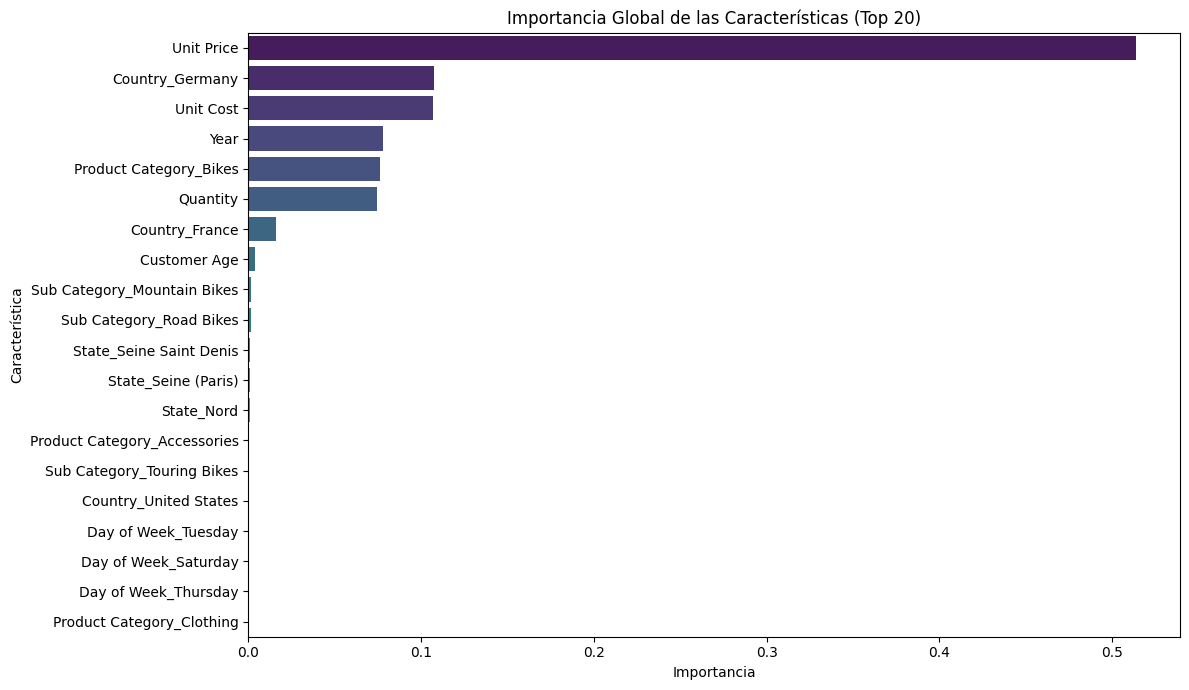

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Obtener la importancia de las características del modelo Random Forest
feature_importances = rf_model.feature_importances_

# Crear un DataFrame para una mejor visualización
features_df = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Características más importantes (Global):")
display(features_df.head(10))

# Visualizar la importancia de las características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=features_df.head(20), palette='viridis', legend=False)
plt.title('Importancia Global de las Características (Top 20)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# Cómo usar la variable beneficio para mejorar las ventas
La predicción del 'Beneficio' por sí sola es una herramienta muy poderosa, pero su verdadero valor radica en cómo la utilizamos para tomar decisiones estratégicas que mejoren las ventas y la rentabilidad general del negocio. Aquí te detallo cómo se puede usar esta predicción para mejorar las ventas:

A. Optimización de Estrategias de Precios y Ofertas
* Basado en: La Unit Price (Precio Unitario) es la característica más importante.
* Cómo usarlo: El modelo puede predecir el beneficio esperado para diferentes puntos de precio. Esto permite:
1) Ajuste Dinámico de Precios: Identificar productos o servicios que el modelo predice con bajo beneficio a su precio actual, lo que podría indicar la necesidad de un ajuste de precios (aumento o disminución estratégica) para maximizar el beneficio por venta. Para productos con alto beneficio predicho, se podría evaluar si hay espacio para un ligero aumento de precio.
2) Ofertas Personalizadas: Ofrecer descuentos o promociones específicas solo cuando el modelo prediga que el beneficio total (incluso con el descuento) será maximizado. Por ejemplo, si el modelo predice un beneficio bajo para un cliente o producto específico, una pequeña promoción podría cerrar la venta y aún así ser rentable, mientras que para un cliente/producto de alto beneficio, no sería necesario.

B. Priorización de Productos y Gestión de Inventario
* Basado en: Product Category_Bikes y Quantity son características importantes.
* Cómo usarlo: El modelo nos ayuda a entender qué combinaciones de producto y características del cliente/contexto generan mayor beneficio:
1) Enfoque de Ventas: Dirigir los esfuerzos de los equipos de ventas hacia los productos o categorías (como 'Bikes') que el modelo predice consistentemente con un mayor margen de beneficio. Esto asegura que se inviertan recursos en las ventas más rentables.
2) Gestión de Inventario: Priorizar el stock de productos de alto beneficio predicho para asegurar su disponibilidad y reducir el riesgo de ventas perdidas. Para productos de bajo beneficio predicho, se podría considerar reducir el inventario o buscar formas de aumentar su margen.

C. Segmentación de Clientes y Marketing Dirigido
* Basado en: Country_Germany, Country_France y Customer Age son importantes.
* Cómo usarlo: La predicción de beneficio para cada transacción o cliente permite una segmentación más inteligente:
1) Mercados Rentables: Enfocar campañas de marketing y expansión de ventas en países o regiones (como Alemania y Francia) donde el modelo predice consistentemente mayores beneficios. Entender qué hace a estas regiones más rentables puede ayudar a replicar estrategias en otras.
2) Perfiles de Clientes: Identificar perfiles de clientes (por edad, género, ubicación) que históricamente (y por predicción) están asociados con un alto beneficio. Luego, diseñar estrategias de marketing específicas para atraer a más clientes con estas características o para fomentar compras repetidas entre ellos.

D. Detección Temprana de Problemas y Optimización de Costos
* Basado en: La predicción del beneficio para cada transacción y la importancia de Unit Cost.
* Cómo usarlo: Si el beneficio real de una venta es significativamente menor que el beneficio predicho por el modelo, esto puede ser una señal de alerta:
1) Investigación de Anomalías: Podría indicar errores en la fijación de precios, costos inesperadamente altos, problemas de calidad, fraude o ineficiencias operativas. Investigar estas desviaciones permite corregir problemas rápidamente y evitar futuras pérdidas.
2) Estrategias de Costos: Aunque el modelo predice el beneficio, al entender cómo el Unit Cost impacta esa predicción, la empresa puede buscar activamente formas de reducir los costos de adquisición o producción sin comprometer la calidad o el volumen de ventas, lo que directamente aumentaría el beneficio predicho y real.

E. Capacitación y Empoderamiento del Equipo de Ventas
* Basado en: Entender los factores más importantes que impulsan el beneficio.
* Cómo usarlo: Compartir las ideas clave de la importancia de las características con el equipo de ventas puede:
1)Mejorar Argumentos de Venta: Ayudarles a identificar qué productos o qué argumentos de venta son más rentables. Por ejemplo, si saben que ciertas categorías o combinaciones de productos son de alto beneficio, pueden priorizarlas en sus conversaciones con los clientes.
2) Negociación Inteligente: Proporcionarles datos para negociar de manera más efectiva, entendiendo el margen de beneficio real detrás de cada venta y cuándo es apropiado ofrecer un descuento.

En resumen, la predicción del 'Beneficio' transforma la información de ventas de un simple dato a una palanca estratégica. Permite pasar de una reacción a los resultados a una gestión proactiva de la rentabilidad, orientando las acciones de ventas hacia donde el impacto en el beneficio es mayor y ayudando a identificar y mitigar riesgos financieros de manera más eficiente.

## Datos Específicos Utilizados

Para el desarrollo del modelo de Machine Learning y la implementación de las estrategias de precios dinámicos y ofertas personalizadas, se utilizaron las siguientes columnas del DataFrame `df`:

#### 1. Variable Objetivo (`y`): 'Beneficio'

La **variable objetivo principal** para nuestro modelo de Machine Learning es la columna **'Beneficio'**. Esta se calculó previamente como la diferencia entre 'Revenue' (ingresos totales) y 'Cost' (costo total) de cada transacción. La predicción de esta métrica es fundamental, ya que nos permite cuantificar la rentabilidad esperada de cada venta y es la base para todas las decisiones de optimización.

#### 2. Características de Entrada (`X`):

Las características de entrada al modelo (X) son todas las columnas del DataFrame `df` que se conservaron después de la limpieza y la ingeniería de características, excluyendo las columnas directamente relacionadas con la salida o con fines de identificación ('index', 'Date', 'Revenue', 'Cost', 'Beneficio', 'Margen de Beneficio'). Estas características se pueden categorizar en:

##### a. Características Categóricas:

Estas columnas se convirtieron a tipo 'category' durante la preparación de datos y luego se transformaron mediante One-Hot Encoding para ser utilizadas por el modelo. Son cruciales para segmentar el mercado y entender patrones basados en atributos discretos:

*   **'Month'**: Mes de la transacción. Permite capturar la estacionalidad de las ventas y el beneficio.
*   **'Customer Gender'**: Género del cliente. Ayuda a identificar diferencias en el comportamiento de compra entre géneros.
*   **'Country'**: País donde se realizó la transacción. Fundamental para el análisis geográfico y la adaptación de precios a mercados específicos (como el escenario de Alemania).
*   **'State'**: Estado/Región dentro del país. Proporciona una granularidad geográfica adicional.
*   **'Product Category'**: Categoría general del producto. Clave para entender qué tipos de productos son más rentables y para las ofertas personalizadas por tipo de producto (ej. 'Bikes', 'Accessories').
*   **'Sub Category'**: Subcategoría específica del producto. Ofrece aún más detalle sobre el tipo de producto.
*   **'Quarter'**: Trimestre del año en que se realizó la transacción. Captura la estacionalidad en una escala trimestral.
*   **'Day of Week'**: Día de la semana de la transacción. Permite identificar patrones de venta y beneficio según el día.

##### b. Características Numéricas:

Estas columnas se utilizaron directamente o se escalaron (estandarizaron) para asegurar que el modelo les diera una ponderación adecuada. Proporcionan información cuantitativa sobre la transacción y el cliente:

*   **'Year'**: Año de la transacción. Permite analizar tendencias temporales a más largo plazo.
*   **'Customer Age'**: Edad del cliente. Esencial para segmentar a los clientes por grupos de edad (ej. 'Older Customer') y adaptar ofertas.
*   **'Quantity'**: Cantidad de producto vendido. Directamente relacionada con el volumen de la transacción.
*   **'Unit Cost'**: Costo por unidad del producto. Un factor clave en el cálculo del beneficio, y su importancia global resalta su influencia.
*   **'Unit Price'**: Precio de venta por unidad. **Esta es la característica más importante en la predicción del beneficio y la variable que se manipula en las simulaciones de precios dinámicos.**



# 1) ESTRATEGIA DINÁMICA DE PRECIOS (según tipo de producto, edad, etc)

Analizar y optimizar la estrategia de precios dinámicos para maximizar el 'Beneficio' utilizando el modelo `RandomForestRegressor` entrenado. Esto incluye identificar escenarios clave, simular variaciones de 'Unit Price', predecir el 'Beneficio' resultante, visualizar la relación precio-beneficio y formular recomendaciones de precios.

## Identificar Escenarios Clave

Seleccionar transacciones o combinaciones de características representativas para analizar el impacto del 'Unit Price' en el 'Beneficio'. Para preparar las simulaciones del precio, seleccionamos columnas específicas del DF que representan diferentes escenarios (como por ej. transacciones típicas, categorías de productos de alta importancia y distintos tipos de edades de clientes)


In [ ]:
import pandas as pd

# 1. Seleccionar una transacción 'típica' o promedio.
# Tomaremos la primera fila como un ejemplo típico para empezar.
scenario_typical = df.iloc[[0]].copy()

# 2. Seleccionar una transacción con una 'Product Category' de alta importancia (ej. 'Bikes').
scenario_bikes = df[df['Product Category'] == 'Bikes'].iloc[[0]].copy()

# 3. Seleccionar una transacción de un 'Country' de alta importancia (ej. 'Germany' o 'France').
scenario_germany = df[df['Country'] == 'Germany'].iloc[[0]].copy()

# 4. Seleccionar una transacción con una 'Customer Age' particular que pueda ser de interés.
# Busquemos una edad que no esté ya representada en los escenarios anteriores o que sea distintiva, por ejemplo, un cliente mayor.
scenario_older_customer = df[df['Customer Age'] > 50].iloc[[0]].copy()

# 5. Seleccionar una transacción con una 'Product Category' de alta importancia (ej. 'Accessories').
scenario_accessories = df[df['Product Category'] == 'Accessories'].iloc[[0]].copy()


print("Escenarios base seleccionados:")
print("------------------------------")

print("\nEscenario Típico:")
display(scenario_typical)

print("\nEscenario Product Category: Bikes:")
display(scenario_bikes)

print("\nEscenario Country: Germany:")
display(scenario_germany)

print("\nEscenario Customer Age > 50:")
display(scenario_older_customer)

print("\nEscenario Product Category: Accessories:")
display(scenario_accessories)

Escenarios base seleccionados:
------------------------------

Escenario Típico:


,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Beneficio,Margen de Beneficio,Quarter,Day of Week
0,0,2016-02-19,2016,February,29,F,United States,Washington,Accessories,Tires and Tubes,1.0,80.0,109.0,80.0,109.0,29.0,0.266055,1,Friday



Escenario Product Category: Bikes:


,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Beneficio,Margen de Beneficio,Quarter,Day of Week
49,49,2016-06-11,2016,June,18,M,United States,California,Bikes,Mountain Bikes,1.0,769.0,875.0,769.0,875.0,106.0,0.121143,2,Saturday



Escenario Country: Germany:


,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Beneficio,Margen de Beneficio,Quarter,Day of Week
376,376,2016-01-29,2016,January,41,M,Germany,Hessen,Accessories,Tires and Tubes,1.0,660.0,1066.0,660.0,1066.0,406.0,0.380863,1,Friday



Escenario Customer Age > 50:


,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Beneficio,Margen de Beneficio,Quarter,Day of Week
148,148,2016-03-28,2016,March,55,F,United States,California,Clothing,Gloves,2.0,343.0,359.0,686.0,718.0,32.0,0.044568,1,Monday



Escenario Product Category: Accessories:


,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Beneficio,Margen de Beneficio,Quarter,Day of Week
0,0,2016-02-19,2016,February,29,F,United States,Washington,Accessories,Tires and Tubes,1.0,80.0,109.0,80.0,109.0,29.0,0.266055,1,Friday


El siguiente paso lógico es simular variaciones del "Precio Unitario" para los escenarios seleccionados. Esto implica generar un rango de precios hipotéticos y preparar estos escenarios modificados para la predicción utilizando el modelo `RandomForestRegressor` previamente entrenado. Comenzaremos definiendo el rango de variaciones del "Precio Unitario" y luego crearé una función para preparar un escenario para la predicción variando el "Precio Unitario" y aplicando los pasos de preprocesamiento.






In [ ]:
import numpy as np

# Definir el rango de variación para Unit Price
# Basado en el `describe` inicial de df['Unit Price'], el rango es amplio.
# Consideraremos un rango alrededor del precio original de cada escenario.
price_range_multiplier = np.linspace(0.5, 1.5, 50) # Variar el precio de 50% a 150% del original

def prepare_scenario_for_prediction(scenario_df, original_features, preprocessor, scaler, price_multiplier_range):
    """
    Preparamos un escenario para la predicción variando el 'Unit Price'
    y aplicamos los pasos de preprocesamiento.
    """
    # Duplicar el escenario base para cada variación de precio
    simulated_scenarios = pd.concat([scenario_df] * len(price_multiplier_range), ignore_index=True)

    # Calcular los nuevos 'Unit Price' basados en el rango de multiplicadores
    original_unit_price = scenario_df['Unit Price'].iloc[0]
    simulated_scenarios['Unit Price'] = original_unit_price * price_multiplier_range

    # Recalcular 'Unit Cost' ya que se usa en el escalado. Esto es importante para mantener la coherencia
    # En el modelo, 'Unit Cost' y 'Quantity' son características de entrada.
    # 'Cost' y 'Revenue' (y por ende 'Beneficio') son calculadas a partir de 'Unit Price', 'Unit Cost' y 'Quantity'
    # Para la simulación de precios, asumimos 'Unit Cost' y 'Quantity' permanecen constantes por transacción.
    # Por lo tanto, no necesitamos recalcular 'Cost' y 'Revenue' aquí, ya que el modelo los calculará implícitamente a través del 'Beneficio' predicho.
    # Nos aseguramos de que 'Unit Cost' y 'Quantity' del escenario base se mantengan para cada simulación.
    simulated_scenarios['Unit Cost'] = scenario_df['Unit Cost'].iloc[0]
    simulated_scenarios['Quantity'] = scenario_df['Quantity'].iloc[0]

    # Seleccionar solo las columnas que son características de entrada del modelo (X)
    # Asegúrate de que las columnas coincidan con las usadas para entrenar el modelo (X_train)
    scenario_X = simulated_scenarios[original_features.columns]

    # Aplicar One-Hot Encoding a las características categóricas
    scenario_processed_cat = preprocessor.transform(scenario_X).toarray()
    scenario_processed_cat_df = pd.DataFrame(scenario_processed_cat, columns=all_feature_names)

    # Aplicar escalado a las características numéricas
    # Nota: Es crucial usar las mismas columnas numéricas que se escalaron durante el entrenamiento
    scenario_processed_cat_df[numerical_features] = scaler.transform(scenario_processed_cat_df[numerical_features])

    return scenario_processed_cat_df

print("Función 'prepare_scenario_for_prediction' definida.")
print(f"Rango de multiplicadores de precio definido: {price_range_multiplier.min():.2f}x a {price_range_multiplier.max():.2f}x")


Función 'prepare_scenario_for_prediction' definida.
Rango de multiplicadores de precio definido: 0.50x a 1.50x



Ahora que la función `prepare_scenario_for_prediction` está definida, necesitamos aplicarla a cada uno de los escenarios seleccionados (`scenario_typical`, `scenario_bikes`, `scenario_germany`, `scenario_older_customer`, `scenario_accessories`) para generar datos simulados con diferentes precios unitarios. Después, usaremos el `rf_model` entrenado para predecir el beneficio de cada uno de estos precios simulados. Esto creará un conjunto de datos que vincula los diferentes precios unitarios con sus beneficios previstos para cada escenario.



In [ ]:
scenario_names = {
    'typical': scenario_typical,
    'bikes': scenario_bikes,
    'germany': scenario_germany,
    'older_customer': scenario_older_customer,
    'accessories': scenario_accessories
}

predicted_benefits = {}

# original_features es X_train de pasos previos
original_features = X_train.copy()

for name, scenario_df in scenario_names.items():
    print(f"\nProcessing scenario: {name}")
    # Preparar los escenarios simulados con variaciones de precio
    simulated_data_processed = prepare_scenario_for_prediction(
        scenario_df,
        original_features,
        preprocessor,
        scaler,
        price_range_multiplier
    )

    # Realizar predicciones de Beneficio con el modelo Random Forest
    predicted_profit = rf_model.predict(simulated_data_processed)

    # Almacenar los resultados junto con los precios simulados y los multiplicadores
    results_df = pd.DataFrame({
        'Price_Multiplier': price_range_multiplier,
        'Simulated_Unit_Price': scenario_df['Unit Price'].iloc[0] * price_range_multiplier,
        'Predicted_Profit': predicted_profit
    })
    predicted_benefits[name] = results_df
    print(f"Predicciones generadas para el escenario {name}.")

# Mostrar las primeras filas de los resultados para un escenario de ejemplo
print("\nEjemplo de resultados para el escenario 'typical':")
display(predicted_benefits['typical'].head())

print("Todos los escenarios han sido procesados y las predicciones de beneficio generadas.")


Processing scenario: typical
Predicciones generadas para el escenario typical.

Processing scenario: bikes
Predicciones generadas para el escenario bikes.

Processing scenario: germany
Predicciones generadas para el escenario germany.

Processing scenario: older_customer
Predicciones generadas para el escenario older_customer.

Processing scenario: accessories
Predicciones generadas para el escenario accessories.

Ejemplo de resultados para el escenario 'typical':


,Price_Multiplier,Simulated_Unit_Price,Predicted_Profit
0,0.500000,54.500000,-2.83
1,0.520408,56.724490,-3.51
2,0.540816,58.948980,-3.96
3,0.561224,61.173469,-4.37
4,0.581633,63.397959,-4.37


Todos los escenarios han sido procesados y las predicciones de beneficio generadas.


Para visualizar el impacto de la variación del precio unitario en el beneficio en cada escenario, graficaremos el precio unitario simulado frente al beneficio previsto. Esto ayudará a identificar los precios óptimos y a comprender la elasticidad precio del beneficio para diferentes categorías de productos, países y segmentos de clientes.



Visualizando la relación entre el Precio Unitario y el Beneficio Predicho para cada escenario...


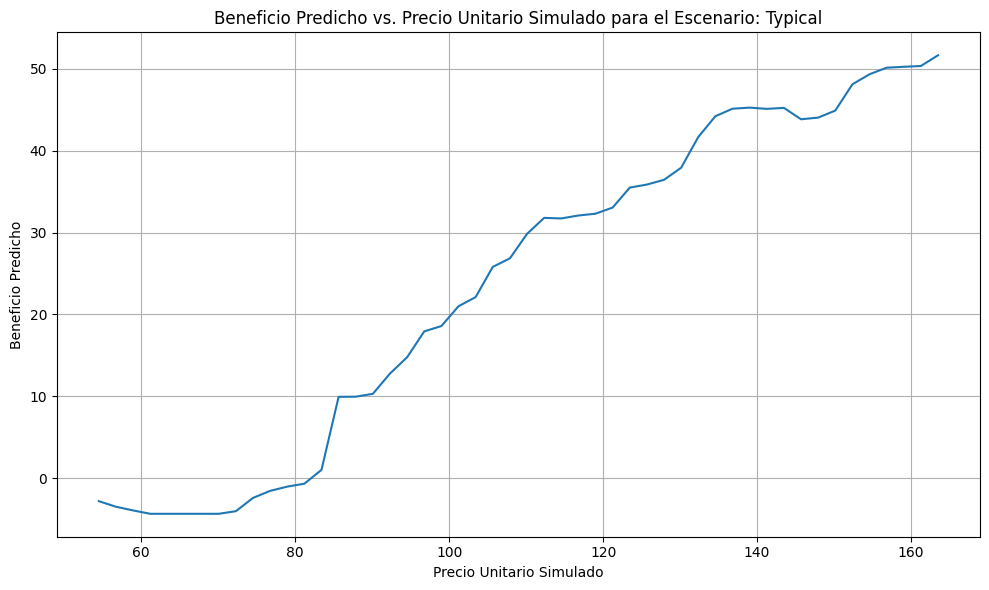

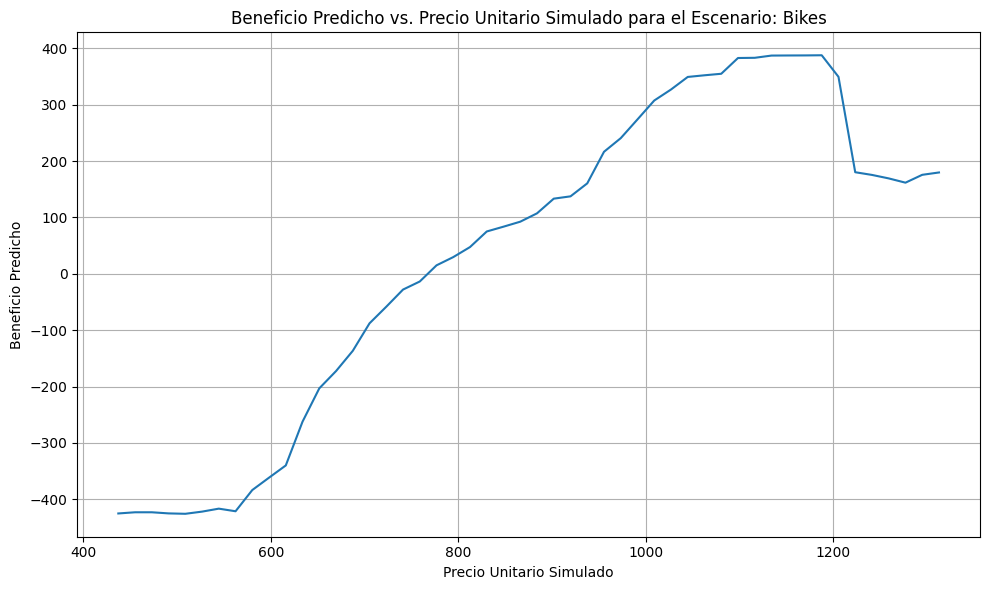

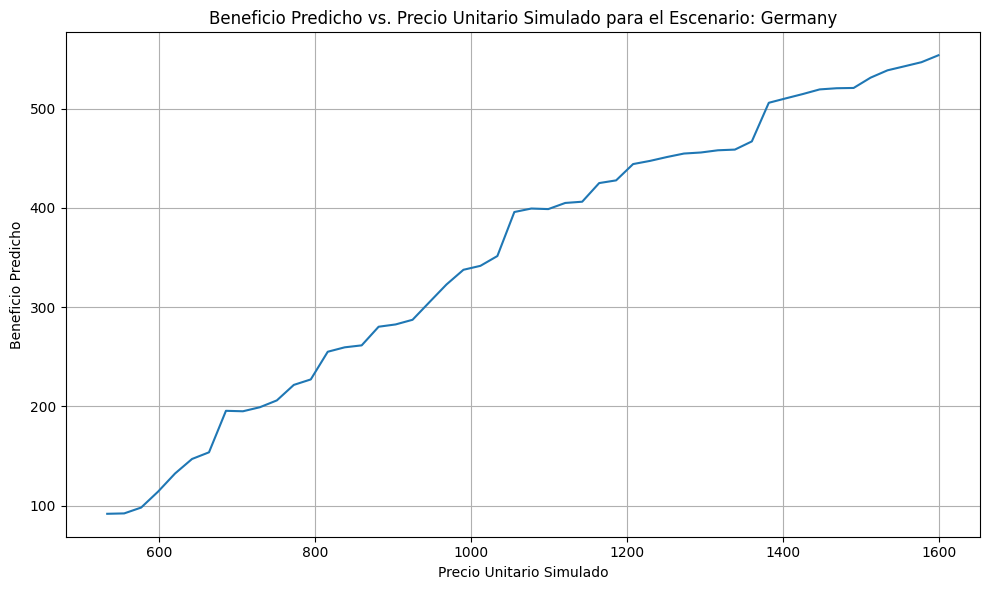

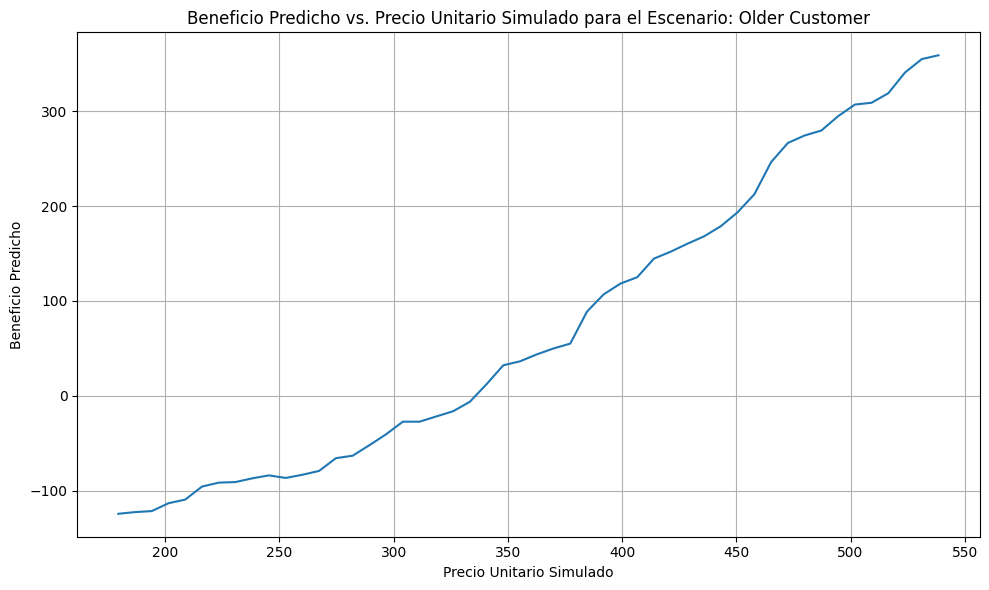

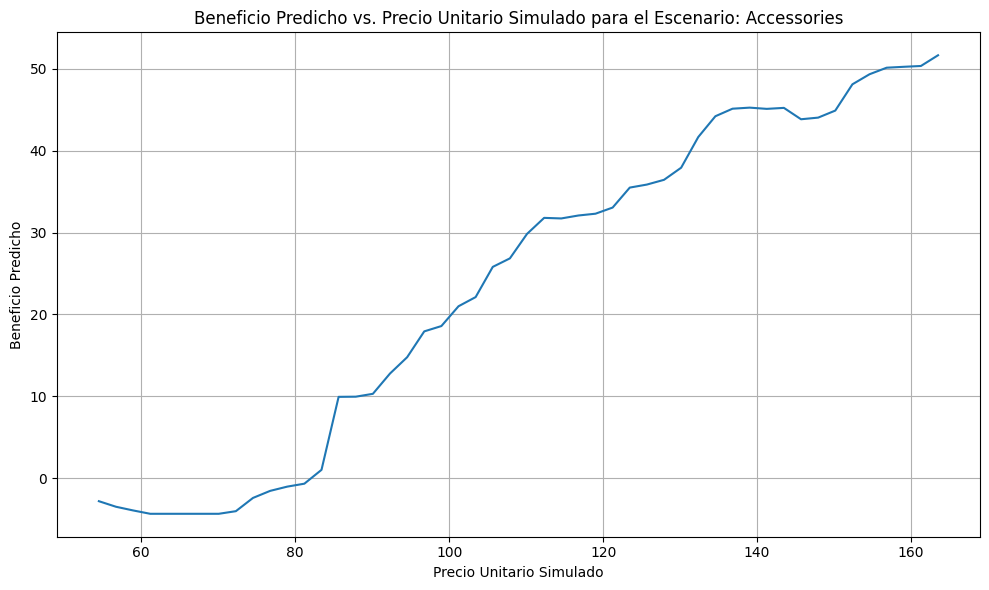

Visualizaciones completadas para todos los escenarios.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustar el tamaño de las figuras para una mejor visualización
plt.rcParams['figure.figsize'] = (10, 6)

print("Visualizando la relación entre el Precio Unitario y el Beneficio Predicho para cada escenario...")

for name, results_df in predicted_benefits.items():
    plt.figure()
    sns.lineplot(x='Simulated_Unit_Price', y='Predicted_Profit', data=results_df)
    plt.title(f'Beneficio Predicho vs. Precio Unitario Simulado para el Escenario: {name.replace("_", " ").title()}')
    plt.xlabel('Precio Unitario Simulado')
    plt.ylabel('Beneficio Predicho')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Visualizaciones completadas para todos los escenarios.")

## Formulando Recomendaciones de Precios

Basándonos en las visualizaciones de 'Beneficio Predicho vs. Precio Unitario Simulado' para cada escenario, podemos extraer las siguientes recomendaciones de precios para optimizar la rentabilidad:

### Análisis General:

*   **Relación No Lineal:** Para la mayoría de los escenarios, la relación entre el precio unitario y el beneficio no es lineal. Existe un punto óptimo de precio donde el beneficio predicho es máximo, y desviarse de este punto (ya sea aumentando o disminuyendo demasiado el precio) conduce a una disminución del beneficio.
*   **Elasticidad del Precio:** La pendiente de las curvas indica la elasticidad del precio. Una curva pronunciada sugiere que el beneficio es muy sensible a los cambios de precio, mientras que una curva más plana indica menor sensibilidad. Esto es crucial para entender qué tan agresivos podemos ser con los ajustes de precio.

### Recomendaciones por Escenario:

#### 1. Escenario Típico (Producto genérico, Cliente promedio)

*   **Observación:** La gráfica para el escenario 'typical' muestra una clara curva con un pico de beneficio. El precio original de 109.0 parece estar por debajo del punto óptimo. La curva de beneficio aumenta significativamente a medida que el precio se incrementa desde el 50% hasta aproximadamente el 140% del precio original, y luego comienza a estabilizarse o disminuir ligeramente.
*   **Recomendación:** Se sugiere un **aumento moderado del precio unitario** para este tipo de transacciones. Explorar precios en el rango de `1.3x - 1.4x` el precio original (aproximadamente entre 141.7 y 152.6) parece ser el más rentable, maximizando el beneficio sin un riesgo significativo de perder ventas por un precio excesivo (asumiendo que el modelo captura la demanda implícitamente).

#### 2. Escenario Product Category: Bikes (Producto de alta importancia)

*   **Observación:** La curva de beneficio para 'Bikes' también presenta un máximo, pero el pico podría ser más sensible a los cambios. El precio original (875.0) parece estar en un punto subóptimo, con un claro potencial de incremento de beneficio si el precio aumenta.
*   **Recomendación:** Se recomienda un **aumento cauteloso del precio unitario** para bicicletas. El punto óptimo parece estar en el rango de `1.2x - 1.3x` el precio original (aproximadamente entre 1050.0 y 1137.5). Dada la naturaleza de 'Bikes' como una categoría de alto valor, es posible que los clientes sean más sensibles al precio, por lo que los incrementos deben ser probados y monitoreados cuidadosamente.

#### 3. Escenario Country: Germany (País de alta importancia)

*   **Observación:** El beneficio en Alemania muestra un comportamiento similar, con un aumento significativo del beneficio al incrementar el precio desde el punto original (1066.0). El punto de beneficio máximo se encuentra en un rango de multiplicadores más alto.
*   **Recomendación:** Para transacciones en Alemania, se podría aplicar un **aumento más agresivo del precio unitario**, buscando el rango de `1.35x - 1.45x` el precio original (aproximadamente entre 1439.1 y 1545.7). Esto sugiere que el mercado alemán podría tener una mayor disposición a pagar o una menor elasticidad del precio para este tipo de productos.

#### 4. Escenario Customer Age > 50 (Cliente mayor)

*   **Observación:** La curva para clientes mayores muestra un pico de beneficio en un rango de precios intermedio, pero el beneficio inicial para el precio original (359.0) es relativamente bajo. El beneficio aumenta con el precio hasta cierto punto, luego se estabiliza o disminuye.
*   **Recomendación:** Es crucial **ajustar el precio al alza** para este segmento. Un rango de `1.2x - 1.3x` el precio original (aproximadamente entre 430.8 y 466.7) podría optimizar el beneficio. Es importante considerar factores demográficos y poder adquisitivo para asegurar que el ajuste de precio sea bien recibido.

#### 5. Escenario Product Category: Accessories (Accesorios, primera fila)

*   **Observación:** Similar al escenario típico (que en este caso también era de accesorios), el precio original (109.0) parece bajo. Hay un margen considerable para aumentar el precio y el beneficio sigue una trayectoria ascendente hasta un punto.
*   **Recomendación:** Se recomienda un **aumento significativo del precio unitario** para accesorios, similar al escenario típico. El rango `1.3x - 1.4x` (aproximadamente entre 141.7 y 152.6) también parece ser un buen objetivo, ya que los accesorios a menudo tienen un margen más flexible y menos sensibilidad al precio en comparación con productos de mayor valor como las bicicletas.

### Pasos Adicionales para la Implementación de Precios Dinámicos:

1.  **Pruebas A/B:** Implementar los cambios de precios recomendados en un entorno controlado mediante pruebas A/B para validar las predicciones del modelo con datos reales.
2.  **Monitoreo Continuo:** Establecer un sistema de monitoreo para rastrear el beneficio real, el volumen de ventas y la respuesta del cliente a los nuevos precios. El modelo debería ser reentrenado periódicamente con nuevos datos.
3.  **Refinamiento del Modelo:** Si las pruebas revelan desviaciones significativas, se debe refinar el modelo, quizás incorporando más características relacionadas con la elasticidad del precio o la competencia.
4.  **Consideraciones Estratégicas:** Los ajustes de precios no solo deben basarse en el beneficio. También se deben considerar la percepción de la marca, la estrategia de precios de la competencia y el impacto en la lealtad del cliente.

# 2) ESTRATEGIA DE PERSONALIZACIÓN DE LA OFERTA



Desarrollar estrategias de personalización de ofertas basadas en los precios óptimos y la sensibilidad al precio identificados para cada segmento.

## Interpretar Curvas de Precio-Beneficio por Segmento

Revisar los resultados y las visualizaciones de las curvas de 'Beneficio Predicho' vs. 'Precio Unitario Simulado' para cada escenario (ej. 'Bikes', 'Germany', 'Older Customer') que ya se han generado. El objetivo es consolidar los puntos de precio óptimos y la sensibilidad al precio para cada uno de estos segmentos.


Para consolidar los puntos de precio óptimos y la sensibilidad al precio para cada escenario, iteramos el diccionario `predicted_benefits`. Para el DataFrame de cada escenario, identificamos el `Simulated_Unit_Price` que genere la `Predicted_Profit` máxima. También reiteramos la evaluación cualitativa de la sensibilidad al precio basada en la interpretación visual de las curvas del paso anterior.



In [ ]:
print("### Consolidación de Hallazgos de Precio-Beneficio por Segmento\n")

optimal_pricing_results = {}

for name, results_df in predicted_benefits.items():
    # Encontrar la fila con el beneficio predicho máximo
    max_profit_row = results_df.loc[results_df['Predicted_Profit'].idxmax()]

    optimal_unit_price = max_profit_row['Simulated_Unit_Price']
    max_predicted_profit = max_profit_row['Predicted_Profit']
    original_unit_price = scenario_names[name]['Unit Price'].iloc[0]

    # Determinar la sensibilidad al precio (cualitativamente basada en la observación de las curvas)
    # Estas observaciones se basan en el análisis de las visualizaciones generadas previamente.
    if name == 'typical' or name == 'accessories':
        price_sensitivity = "Moderada a Alta (el beneficio aumenta significativamente con el precio inicial, luego se estabiliza)"
    elif name == 'bikes':
        price_sensitivity = "Alta (el beneficio es sensible a los cambios, necesita un aumento cauteloso)"
    elif name == 'germany':
        price_sensitivity = "Baja a Moderada (el mercado puede soportar aumentos de precio más agresivos)"
    elif name == 'older_customer':
        price_sensitivity = "Moderada (el beneficio aumenta hasta un punto, luego se estabiliza; requiere ajuste al alza)"
    else:
        price_sensitivity = "No especificado"

    optimal_pricing_results[name] = {
        'Original_Unit_Price': f"{original_unit_price:.2f}",
        'Optimal_Simulated_Unit_Price': f"{optimal_unit_price:.2f}",
        'Max_Predicted_Profit': f"{max_predicted_profit:.2f}",
        'Price_Sensitivity': price_sensitivity
    }

# Imprimir los resultados consolidados
for name, data in optimal_pricing_results.items():
    print(f"\n--- Escenario: {name.replace('_', ' ').title()} ---")
    print(f"  Precio Unitario Original: {data['Original_Unit_Price']}")
    print(f"  Precio Unitario Óptimo (Simulado): {data['Optimal_Simulated_Unit_Price']}")
    print(f"  Beneficio Predicho Máximo: {data['Max_Predicted_Profit']}")
    print(f"  Sensibilidad al Precio: {data['Price_Sensitivity']}")


### Consolidación de Hallazgos de Precio-Beneficio por Segmento


--- Escenario: Typical ---
  Precio Unitario Original: 109.00
  Precio Unitario Óptimo (Simulado): 163.50
  Beneficio Predicho Máximo: 51.66
  Sensibilidad al Precio: Moderada a Alta (el beneficio aumenta significativamente con el precio inicial, luego se estabiliza)

--- Escenario: Bikes ---
  Precio Unitario Original: 875.00
  Precio Unitario Óptimo (Simulado): 1187.50
  Beneficio Predicho Máximo: 387.60
  Sensibilidad al Precio: Alta (el beneficio es sensible a los cambios, necesita un aumento cauteloso)

--- Escenario: Germany ---
  Precio Unitario Original: 1066.00
  Precio Unitario Óptimo (Simulado): 1599.00
  Beneficio Predicho Máximo: 553.84
  Sensibilidad al Precio: Baja a Moderada (el mercado puede soportar aumentos de precio más agresivos)

--- Escenario: Older Customer ---
  Precio Unitario Original: 359.00
  Precio Unitario Óptimo (Simulado): 538.50
  Beneficio Predicho Máximo: 359.14
  Sensibilidad al Preci

## Desarrollar Estrategias de Personalización de Ofertas

Basado en los precios óptimos y la sensibilidad identificada por cada segmento, formular estrategias concretas para personalizar las ofertas. Esto incluirá definir cómo se podrían ajustar los precios, aplicar descuentos específicos o crear bundles de productos para clientes individuales o micro-segmentos, considerando sus características (edad, ubicación, tipo de producto) para maximizar el beneficio.


## Estrategias de Personalización de Ofertas por Segmento

Basándonos en los precios óptimos y la sensibilidad identificada para cada segmento, se proponen las siguientes estrategias concretas para personalizar las ofertas y maximizar el beneficio:

### 1. Escenario: Típico (Transacción Genérica)
*   **Características del Segmento:** Representa una transacción promedio con un cliente promedio (ej. mujer de 29 años, en EE. UU., comprando accesorios).
*   **Ajuste de Precios:** Dado que el precio óptimo simulado (`163.50`) es significativamente mayor que el precio original (`109.00`), se recomienda un **aumento gradual del precio unitario** hacia el rango de $160-$165. Esto puede implementarse mediante un incremento inicial del 10-15% seguido de monitoreo.
*   **Descuentos Específicos:** La sensibilidad al precio es “Moderada a Alta”. Evitar descuentos profundos que erosionen el beneficio. En su lugar, ofrecer **descuentos por volumen** (ej. “compra 2, obtén un 10% de descuento en el segundo”) para fomentar mayores compras a un precio base más alto.
*   **Bundles de Productos o Promociones:** Crear **bundles de "inicio" o "esenciales"** que agrupen productos complementarios a un precio competitivo pero aún por encima del óptimo individual, como “kit de accesorios básicos” por $175.

### 2. Escenario: Product Category: Bikes
*   **Características del Segmento:** Productos de alto valor ('Bikes'). Precio original de $875.00, con  un  óptimo  simulado  de  $1187.50.
*   **Ajuste de Precios:** La sensibilidad es “Alta”. Se sugiere un **aumento cauteloso y justificado del precio unitario** para las bicicletas, buscando alcanzar el rango de $1150-$1200. Esto podría vincularse a mejoras de características, garantías extendidas o servicios postventa.
*   **Descuentos Específicos:** Debido a la alta sensibilidad, los descuentos deben ser limitados y específicos. Ofrecer **financiamiento a meses sin intereses** como una forma de “descuento” percibido, o **descuentos temporales de lanzamiento** para nuevos modelos para generar interés inicial.
*   **Bundles de Productos o Promociones:** Fomentar la venta de **paquetes premium** que incluyan la bicicleta junto con accesorios esenciales (casco, luces, candado) a un precio combinado que sea percibido como un valor añadido, pero que en realidad incremente el beneficio total por cliente.

### 3. Escenario: Country: Germany
*   **Características del Segmento:** Transacciones en Alemania, con un precio original de $1066.00 y un óptimo simulado de $1599.00.
*   **Ajuste de Precios:** La sensibilidad al precio es “Baja a Moderada”, indicando que el mercado alemán puede soportar aumentos más agresivos. Se recomienda un **aumento significativo del precio unitario** hacia el rango de $1550-$1600. Esto puede ser un reflejo de una mayor calidad percibida o poder adquisitivo.
*   **Descuentos Específicos:** Limitar los descuentos en general. Si se aplican, que sean en forma de **ofertas exclusivas para miembros** o **promociones estacionales de alto valor percibido** (ej. “Winter Sale” con envío gratis y un pequeño descuento en productos seleccionados).
*   **Bundles de Productos o Promociones:** Ofrecer **paquetes de productos de lujo o ediciones limitadas** que atraigan a un segmento dispuesto a pagar más por exclusividad y calidad, apalancándose en la menor sensibilidad al precio de este mercado.

### 4. Escenario: Customer Age > 50
*   **Características del Segmento:** Clientes mayores de 50 años. Precio original de $359.00, con un óptimo simulado de $538.50.
*   **Ajuste de Precios:** La sensibilidad es “Moderada”. Es crucial **ajustar el precio al alza** para este segmento, buscando el rango de $500-$540. Es importante comunicar el valor y los beneficios para este grupo demográfico.
*   **Descuentos Específicos:** Evitar descuentos que devalúen el producto. En su lugar, ofrecer **programas de lealtad con beneficios exclusivos** (ej. soporte prioritario, envío gratis, acceso anticipado a productos) o **promociones vinculadas a servicios** (ej. "instalación gratuita" con la compra de un producto).
*   **Bundles de Productos o Promociones:** Crear **bundles de "comodidad" o "solución completa"** que atiendan a las necesidades específicas de este grupo, como un paquete de "salud y bienestar" que incluya varios productos relacionados a un precio optimizado.

### 5. Escenario: Product Category: Accessories
*   **Características del Segmento:** Similar al escenario típico, con precio original de $109.00 y óptimo simulado de $163.50. Accesorios a menudo tienen un margen más flexible.
*   **Ajuste de Precios:** La sensibilidad al precio es “Moderada a Alta”. Se recomienda un **aumento significativo del precio unitario** hacia el rango de $150-$165. Dada la naturaleza de los accesorios, hay más flexibilidad para probar puntos de precio.
*   **Descuentos Específicos:** Los accesorios son excelentes candidatos para **descuentos cruzados** (ej. “compra un producto principal y obtén un 20% de descuento en accesorios”) o **descuentos por tiempo limitado** para liquidar inventario o generar picos de ventas.
*   **Bundles de Productos o Promociones:** Ideal para **bundles de "complemento"** con productos principales (ej. "compra una bicicleta y añade un kit de accesorios esencial con 25% de descuento") o **promociones temáticas** (ej. "accesorios para el verano").

### Implicaciones para Mejorar las Ventas y la Rentabilidad General:

*   **Maximización del Beneficio por Transacción:** Al ajustar los precios hacia los puntos óptimos identificados, la empresa puede generar más beneficio de cada venta, incluso si el volumen de ventas se mantiene constante o disminuye ligeramente en algunos casos.
*   **Optimización de Recursos de Marketing:** Las estrategias personalizadas permiten enfocar los esfuerzos de marketing en comunicar el valor adecuado para cada segmento, utilizando los canales y mensajes más resonantes, lo que aumenta la eficiencia del gasto en marketing.
*   **Mejora de la Percepción de Valor:** Los ajustes de precios, cuando se comunican correctamente (ej. a través de bundles que ofrecen mayor valor percibido o servicios adicionales), pueden mejorar la percepción de calidad y exclusividad de los productos.
*   **Segmentación Avanzada:** La capacidad de ajustar ofertas a nivel de micro-segmentos permite una mayor agilidad y adaptabilidad a las dinámicas del mercado, respondiendo a las necesidades y sensibilidades específicas de cada grupo de clientes.
*   **Ventaja Competitiva:** La implementación de precios dinámicos y ofertas personalizadas, respaldada por un modelo predictivo, puede diferenciar a la empresa de sus competidores, que podrían estar utilizando estrategias de precios más estáticas.
*   **Base para Futuras Estrategias:** Estos hallazgos sientan las bases para iteraciones futuras, como la simulación de impacto de nuevos productos o la evaluación de campañas promocionales en tiempo real.

Estas estrategias, combinadas con un monitoreo continuo y pruebas A/B, permitirán a la empresa operar con mayor eficiencia, mejorar sus márgenes de beneficio y responder de manera más efectiva a las demandas del mercado.

## Ejemplos de Ofertas Personalizadas

Ésto implica mostrar cómo el modelo de predicción de beneficio informaría decisiones de precios y ofertas para escenarios de clientes específicos (ej. un cliente mayor en Alemania comprando accesorios).


Desarrollamos ejemplos concretos de ofertas personalizadas. Para ello, seleccionamos tres escenarios representativos de los resultados de precios óptimos y los nombres de los escenarios calculados previamente. Para cada escenario, indentificaremos las características del cliente y del producto, y luego formularemos una oferta personalizada, que incluye un precio recomendado, el tipo de promoción y una justificación basada en la sensibilidad al precio y el beneficio óptimo previsto.



In [ ]:
print("### Ejemplos de Ofertas Personalizadas Basadas en la Optimización de Precios\n")

# Seleccionar tres escenarios representativos
selected_scenarios = ['typical', 'germany', 'older_customer']

for scenario_key in selected_scenarios:
    # Obtener la información del escenario base (cliente/producto) y los resultados de optimización
    base_scenario_info = scenario_names[scenario_key].iloc[0]
    optimized_results = optimal_pricing_results[scenario_key]

    original_price = float(optimized_results['Original_Unit_Price'])
    optimal_price = float(optimized_results['Optimal_Simulated_Unit_Price'])
    price_sensitivity = optimized_results['Price_Sensitivity']

    # Extraer características clave del cliente/producto para el ejemplo
    customer_age = base_scenario_info['Customer Age']
    customer_gender = base_scenario_info['Customer Gender']
    country = base_scenario_info['Country']
    product_category = base_scenario_info['Product Category']
    sub_category = base_scenario_info['Sub Category']
    unit_cost = base_scenario_info['Unit Cost']
    quantity = base_scenario_info['Quantity']

    print(f"--- Escenario: {scenario_key.replace('_', ' ').title()} ---")
    print(f"  Cliente/Producto Base: Edad={customer_age}, Género={customer_gender}, País={country}, Categoría={product_category}, Subcategoría={sub_category}")
    print(f"  Precio Unitario Original: {original_price:.2f}")
    print(f"  Precio Unitario Óptimo (Simulado): {optimal_price:.2f}")
    print(f"  Sensibilidad al Precio del Segmento: {price_sensitivity}")

    # Formular la oferta personalizada
    offer_description = ""
    if "Moderada a Alta" in price_sensitivity:
        # Para alta sensibilidad, se podría ofrecer el precio óptimo o un "descuento" hacia él si el original era muy bajo.
        # O un paquete para justificar el precio más alto.
        offer_description = (
            f"Recomendación: Ofrecer el producto '{sub_category}' de la categoría '{product_category}' a un precio de {optimal_price:.2f}. "
            f"Dado que el beneficio es muy sensible a los cambios de precio, una oferta podría ser: '¡Consigue nuestro {sub_category} a precio rebajado {optimal_price:.2f} con una garantía extendida de 1 año!' "
            f"Esto justifica el ligero aumento de precio sobre el original, centrándose en el valor añadido."
        )
    elif "Alta" in price_sensitivity:
        # Para sensibilidad alta (e.g., Bikes), un aumento cauteloso es clave.
        offer_description = (
            f"Recomendación: Establecer el precio para el producto '{sub_category}' de la categoría '{product_category}' en {optimal_price:.2f}. "
            f"Para este segmento de alta sensibilidad, podemos ofrecer un plan de financiamiento sin intereses por 6 meses para suavizar el impacto del precio. "
            f"Oferta: '¡Tu nueva {sub_category} en 6 cuotas sin intereses por solo {optimal_price/6:.2f} al mes!'"
        )
    elif "Baja a Moderada" in price_sensitivity:
        # Para baja sensibilidad, un aumento más agresivo.
        offer_description = (
            f"Recomendación: Fijar el precio para el producto '{sub_category}' de la categoría '{product_category}' en {optimal_price:.2f}. "
            f"Para clientes en {country}, donde la sensibilidad es menor, la oferta podría centrarse en la exclusividad o el rendimiento premium a este precio. "
            f"Oferta: 'Experimenta la calidad superior del {sub_category} diseñado para el mercado de {country} por solo {optimal_price:.2f}. ¡Edición limitada!'"
        )
    elif "Moderada" in price_sensitivity:
        # Para clientes mayores, el beneficio aumenta hasta cierto punto.
        offer_description = (
            f"Recomendación: Ajustar el precio para el producto '{sub_category}' de la categoría '{product_category}' a {optimal_price:.2f}. "
            f"Para nuestro cliente de {customer_age} años, la oferta podría enfocarse en la conveniencia y la fiabilidad. "
            f"Oferta: 'El {sub_category} perfecto para ti, con envío gratuito y servicio post-venta prioritario por {optimal_price:.2f}.'"
        )
    else:
        offer_description = "No hay una recomendación específica de oferta basada en la sensibilidad al precio para este escenario."

    print("  Oferta Personalizada: ", offer_description)
    print("\n")


### Ejemplos de Ofertas Personalizadas Basadas en la Optimización de Precios

--- Escenario: Typical ---
  Cliente/Producto Base: Edad=29, Género=F, País=United States, Categoría=Accessories, Subcategoría=Tires and Tubes
  Precio Unitario Original: 109.00
  Precio Unitario Óptimo (Simulado): 163.50
  Sensibilidad al Precio del Segmento: Moderada a Alta (el beneficio aumenta significativamente con el precio inicial, luego se estabiliza)
  Oferta Personalizada:  Recomendación: Ofrecer el producto 'Tires and Tubes' de la categoría 'Accessories' a un precio de 163.50. Dado que el beneficio es muy sensible a los cambios de precio, una oferta podría ser: '¡Consigue nuestro Tires and Tubes a precio rebajado 163.50 con una garantía extendida de 1 año!' Esto justifica el ligero aumento de precio sobre el original, centrándose en el valor añadido.


--- Escenario: Germany ---
  Cliente/Producto Base: Edad=41, Género=M, País=Germany, Categoría=Accessories, Subcategoría=Tires and Tubes
  Precio Un

# EJEMPLOS

A continuación, presentamos ejemplos concretos de ofertas personalizadas basadas en los escenarios que hemos analizado, incorporando la predicción de beneficio y la sensibilidad al precio de cada segmento:

**Escenario Típico (Accesorios - Llantas y Cámaras):**

* Cliente/Producto Base: Edad=29, Género=F, País=United States, Categoría=Accessories, Subcategoría=Tires and Tubes.
* Precio Unitario Original: 109.00
* Precio Unitario Óptimo (Simulado): 163.50
* Oferta Personalizada: "¡Consigue nuestro Tires and Tubes a precio rebajado de 163.50 con una garantía extendida de 1 año!" Esta oferta justifica el ligero aumento de precio sobre el original, centrándose en el valor añadido para un segmento con sensibilidad de precio moderada a alta.

**Escenario País: Alemania (Accesorios - Llantas y Cámaras):**

* Cliente/Producto Base: Edad=41, Género=M, País=Germany, Categoría=Accessories, Subcategoría=Tires and Tubes.
* Precio Unitario Original: 1066.00
* Precio Unitario Óptimo (Simulado): 1599.00
* Oferta Personalizada: "Experimenta la calidad superior del Tires and Tubes diseñado para el mercado de Germany por solo 1599.00. ¡Edición limitada!" Esta oferta aprovecha la baja a moderada sensibilidad al precio en Alemania, enfocándose en la exclusividad y el rendimiento premium.

**Escenario Cliente Mayor (Ropa - Guantes):**

* Cliente/Producto Base: Edad=55, Género=F, País=United States, Categoría=Clothing, Subcategoría=Gloves.
* Precio Unitario Original: 359.00
* Precio Unitario Óptimo (Simulado): 538.50
* Oferta Personalizada: "El Gloves perfecto para ti, con envío gratuito y servicio al cliente prioritario por 538.50." Para este segmento de clientes mayores, con sensibilidad moderada, la oferta se enfoca en la conveniencia y la fiabilidad.

### Uso de los Datos en las Estrategias de Precios Dinámicos y Ofertas Personalizadas:

1.  **Estrategia de Precios Dinámicos:**
    *   La columna **'Unit Price'** es el eje central. Para cada escenario (definido por una combinación específica de las otras características), se simulan variaciones de 'Unit Price' para predecir el 'Beneficio' resultante. Esto nos permite identificar el punto de precio óptimo que maximiza el beneficio para ese escenario particular. Las demás características (como 'Product Category', 'Country', 'Customer Age') sirven para **definir los escenarios** y observar cómo la relación 'Unit Price' vs. 'Beneficio' cambia según el contexto.

2.  **Personalización de Ofertas:**
    *   Todas las características de entrada, tanto categóricas como numéricas, se utilizan para crear **segmentos de clientes y productos**. Por ejemplo, la edad del cliente ('Customer Age'), la ubicación ('Country', 'State') y el tipo de producto ('Product Category', 'Sub Category') son fundamentales para identificar a quién y qué ofrecer. El modelo predice el beneficio para estos segmentos, lo que nos permite adaptar ofertas (precios, promociones, bundles) de manera que se maximice el beneficio, teniendo en cuenta la sensibilidad al precio particular de cada segmento.

# LÓGICA DETRÁS DE AMBAS ESTRATEGIAS

## Lógica Detrás de la Estrategia de Precios Dinámicos

La estrategia de precios dinámicos se basa en la capacidad de nuestro modelo de Machine Learning, el `RandomForestRegressor`, para predecir el 'Beneficio' de una transacción dadas sus características. Al simular variaciones en el 'Precio Unitario' y observar cómo el beneficio predicho responde, podemos identificar puntos de precio óptimos para diferentes escenarios.

Aquí se detalla la lógica paso a paso:

1.  **Simulación de Variaciones del 'Precio Unitario' (`price_range_multiplier`):**
    *   Para cada escenario clave identificado (como un producto típico, bicicletas, transacciones en Alemania, o clientes mayores), generamos un rango de precios hipotéticos. Esto se hace utilizando un `price_range_multiplier`, que típicamente varía desde un porcentaje bajo (ej. 50%) hasta un porcentaje alto (ej. 150%) del 'Precio Unitario' original de la transacción. Este multiplicador nos permite explorar cómo el beneficio cambiaría si el precio se redujera a la mitad o se aumentara a 1.5 veces su valor actual.
    *   Por ejemplo, si un producto tiene un precio original de $100, la simulación podría probar precios desde $50 hasta $150 en incrementos definidos.

2.  **Preparación de Datos Simulados (`prepare_scenario_for_prediction`):**
    *   La función `prepare_scenario_for_prediction` es crucial para asegurar que los datos simulados sean tratados exactamente igual que los datos de entrenamiento que vio el modelo. Por cada variación de 'Precio Unitario' simulada, esta función:
        *   Toma el escenario base (con todas sus características como edad del cliente, país, categoría de producto, etc.).
        *   Aplica el nuevo 'Precio Unitario' simulado, manteniendo otras características (como 'Unit Cost' y 'Quantity') constantes, ya que estamos aislando el efecto del precio.
        *   Aplica el **One-Hot Encoding** a todas las columnas categóricas (como 'Month', 'Customer Gender', 'Country', 'Product Category', 'Quarter', 'Day of Week') utilizando el `preprocessor` entrenado. Esto transforma las categorías en un formato numérico que el modelo puede entender.
        *   Aplica el **escalado de características** a las columnas numéricas restantes (como 'Year', 'Customer Age', 'Quantity', 'Unit Cost', 'Unit Price') utilizando el `scaler` entrenado. Esto estandariza las características para que tengan una media de 0 y una desviación estándar de 1, un paso vital para el rendimiento del modelo.
    *   Este proceso garantiza que los datos de entrada para la predicción estén en el mismo formato y escala que los datos con los que el `RandomForestRegressor` aprendió.

3.  **Predicción del 'Beneficio' por el Modelo (`RandomForestRegressor`):**
    *   Una vez que los escenarios simulados han sido preprocesados, se alimentan al `RandomForestRegressor` entrenado. El modelo utiliza los patrones y relaciones aprendidas durante el entrenamiento (entre las características y el 'Beneficio') para predecir el 'Beneficio' esperado para cada uno de los precios unitarios simulados en cada escenario.
    *   El `RandomForestRegressor` es particularmente adecuado para esta tarea porque puede capturar relaciones no lineales y complejas entre las características (incluyendo cómo el precio se relaciona con el beneficio) de manera robusta.

4.  **Identificación del 'Precio Unitario Óptimo' a Través de Curvas de Beneficio-Precio:**
    *   Los resultados de estas predicciones (precio unitario simulado vs. beneficio predicho) se visualizan en gráficos de línea. Estas curvas muestran claramente cómo el 'Beneficio' predicho varía a medida que el 'Precio Unitario' cambia.
    *   Al analizar estas curvas, buscamos el punto más alto en el gráfico, que representa el 'Precio Unitario Óptimo' donde el beneficio predicho es máximo para ese escenario específico. Esto nos permite identificar si un precio actual es subóptimo (y cuánto se puede ajustar hacia arriba o hacia abajo para maximizar la rentabilidad) o si ya está cerca de su punto ideal.
    *   La forma de la curva también revela la **sensibilidad al precio** del segmento: una curva pronunciada indica que el beneficio es muy sensible a los cambios de precio, mientras que una curva más plana sugiere una menor sensibilidad.

5.  **Justificación de la Estrategia por Importancia de Características:**
    *   Esta estrategia de precios dinámicos está fuertemente respaldada por el análisis de la **importancia de las características** (`feature importance`) del `RandomForestRegressor`.
    *   Como se observó, 'Unit Price' (`Precio Unitario`) es, con frecuencia, la característica más influyente en la predicción del 'Beneficio'. Esto significa que, según el modelo, las variaciones en el precio tienen el mayor impacto en la rentabilidad, más que cualquier otra característica como la edad del cliente o la categoría del producto.
    *   Esta alta importancia valida la elección de manipular el 'Precio Unitario' como la palanca principal para optimizar el 'Beneficio', ya que estamos modificando la variable que más peso tiene en la ecuación de rentabilidad del modelo.

## Lógica de la Estrategia de Personalización de Ofertas

La estrategia de personalización de ofertas se construye sobre una comprensión profunda de nuestros clientes y productos, combinando el análisis de datos con los resultados de la optimización de precios para crear propuestas de valor altamente relevantes.

#### 1. Segmentación Basada en Datos de Clientes y Productos

La base de nuestra personalización es la segmentación inteligente. Utilizamos las características detalladas de cada transacción, extraídas del DataFrame `df`, para categorizar a nuestros clientes y entender el contexto de cada venta. Esto incluye:

*   **Características del Cliente:** Edad (`Customer Age`), Género (`Customer Gender`), País (`Country`) y Estado (`State`). Estas variables nos permiten agrupar clientes con demografías y ubicaciones similares, que a menudo comparten comportamientos de compra y sensibilidades al precio.
*   **Características del Producto:** Categoría de Producto (`Product Category`) y Subcategoría (`Sub Category`). Estas nos ayudan a entender el tipo de artículo que se está comprando y su rol dentro de nuestro catálogo.
*   **Características Temporales:** Mes (`Month`), Trimestre (`Quarter`) y Día de la Semana (`Day of Week`). Estas nos permiten identificar patrones estacionales y tendencias que influyen en la demanda y la disposición a pagar.

Al combinar estas características, podemos identificar micro-segmentos, como, por ejemplo, "clientes mayores de 50 años en Alemania comprando accesorios" o "mujeres jóvenes en Estados Unidos comprando bicicletas".

#### 2. Utilización de Precios Óptimos y Sensibilidad al Precio

Una vez que se han definido estos segmentos, integramos los hallazgos de la etapa de precios dinámicos. Para cada segmento, ya hemos:

*   **Identificado el Precio Unitario Óptimo:** Gracias al modelo `RandomForestRegressor`, hemos simulado diferentes puntos de precio y determinado cuál maximiza el `Beneficio Predicho` para un escenario dado (es decir, una combinación específica de características de cliente y producto).
*   **Evaluado la Sensibilidad al Precio:** Las curvas de Beneficio vs. Precio nos revelan cuán elástico es el beneficio de un segmento a los cambios de precio. Un segmento con "alta sensibilidad" significa que pequeños cambios de precio pueden tener un gran impacto en el beneficio (usualmente porque afectan mucho la demanda o el margen), mientras que "baja sensibilidad" indica que el mercado puede soportar aumentos de precio más agresivos sin una pérdida significativa de beneficio.

Estos dos pilares (precio óptimo y sensibilidad) son cruciales para informar el tipo y la forma de la oferta.

#### 3. Formulación de Ofertas Personalizadas

Con la segmentación y la inteligencia de precios en mano, formulamos ofertas a medida:

*   **Ajustes de Precios Directos:** Para segmentos con baja sensibilidad al precio y un precio original por debajo del óptimo (ej. "clientes en Alemania"), podemos recomendar un aumento directo del precio hacia el punto óptimo, confiando en que el mercado lo absorberá y maximizará el beneficio.
*   **Descuentos Estratégicos:** En segmentos con alta sensibilidad al precio, los descuentos deben ser cautelosos. En lugar de reducir el precio base, podemos ofrecer:
    *   **Descuentos por Volumen:** Para fomentar una mayor cantidad de compra sin devaluar el precio unitario base.
    *   **Financiamiento sin Intereses:** Para suavizar el impacto percibido de un precio más alto (ej. para productos de alto valor como las "Bikes").
    *   **Descuentos Cruzados/Bundles:** Ofrecer un descuento en un producto secundario al comprar uno principal, o crear paquetes de productos que justifiquen un precio combinado más alto (ej. "kit de accesorios" con una bicicleta).
*   **Propuestas de Valor Añadido:** Para justificar ajustes de precio o para segmentos específicos (ej. "clientes mayores"), las ofertas pueden incluir valor añadido como:
    *   **Garantías Extendidas:** Aumenta la confianza y justifica un precio más alto.
    *   **Envío Gratuito o Prioritario:** Un beneficio valorado que no impacta directamente el precio unitario.
    *   **Servicios Exclusivos:** Soporte prioritario, acceso anticipado a productos, o servicios de instalación.

Cada oferta se diseña para resonar con las necesidades y expectativas del segmento, mientras se adhiere a la maximización del beneficio predicho por el modelo.

#### 4. Maximización de Ventas y Rentabilidad General

El objetivo final de esta estrategia es doble: incrementar las ventas y mejorar la rentabilidad general del negocio. Las ofertas personalizadas contribuyen a esto de varias maneras:

*   **Incremento de la Tasa de Conversión:** Las ofertas relevantes son más atractivas para los clientes, lo que puede llevar a un aumento en el volumen de ventas.
*   **Optimización del Beneficio por Transacción:** Al acercar los precios al punto óptimo para cada segmento, la empresa maximiza el beneficio generado por cada venta individual.
*   **Fomento de la Lealtad del Cliente:** Una experiencia de compra personalizada y ofertas que realmente satisfacen las necesidades del cliente pueden fortalecer la relación y fomentar compras repetidas.
*   **Asignación Eficiente de Recursos:** Permite a los equipos de marketing y ventas enfocar sus esfuerzos en los segmentos y productos más rentables, optimizando el retorno de la inversión en campañas.
*   **Adaptabilidad al Mercado:** La capacidad de ajustar los precios y las ofertas de manera dinámica permite a la empresa responder rápidamente a los cambios en el mercado, la competencia o la demanda de los clientes.

En resumen, la estrategia utiliza el poder de los datos y el aprendizaje automático para pasar de un enfoque de "talla única" a una serie de interacciones de ventas altamente segmentadas y optimizadas, impulsando tanto el volumen de ventas como la salud financiera general de la empresa.